# M08 vs M09 evaluation

This notebook evaluates whether replacing the global average pooling of M08 with the M09 multi-slot temporal attention pooling improves CBC parameter regression.

Comparison:

- **M08**: residual dilated encoder + `AdaptiveAvgPool1d(1)`
- **M09**: same residual dilated encoder + multi-slot temporal attention pooling

Use the same 500k dataset, same split, same seed, same loss, same optimizer settings, and same evaluation splits.

Primary question:

> Does M09 improve point-estimation accuracy and error tails relative to M08 enough to justify the more complex pooling mechanism?


## 1. Imports and paths

In [1]:
from pathlib import Path
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
RESULTS_ROOT = DATA_ROOT / "results"
CHECKPOINT_ROOT = DATA_ROOT / "models" / "checkpoints"
PROCESSED_ROOT = DATA_ROOT / "processed"

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
DATASET_RESULTS_ROOT = RESULTS_ROOT / DATASET_ID
DATASET_CHECKPOINT_ROOT = CHECKPOINT_ROOT / DATASET_ID
PROCESSED_ROOT = PROCESSED_ROOT / DATASET_ID

PROJECT_ROOT = Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/")
if PROJECT_ROOT.exists() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

LABEL_NAMES = ["chirp_mass", "total_mass", "chi_eff"]
SPLITS = ["val", "cal", "test"]

print("DATASET_RESULTS_ROOT:", DATASET_RESULTS_ROOT, DATASET_RESULTS_ROOT.exists())
print("DATASET_CHECKPOINT_ROOT:", DATASET_CHECKPOINT_ROOT, DATASET_CHECKPOINT_ROOT.exists())
print("PROJECT_ROOT:", PROJECT_ROOT, PROJECT_ROOT.exists())

DATASET_RESULTS_ROOT: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True
DATASET_CHECKPOINT_ROOT: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True
PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe True


## 2. Resolve files

Review the selected files before continuing. The filename patterns are flexible to tolerate small naming differences.

In [2]:
def resolve_file(root: Path, patterns, description: str) -> Path:
    if isinstance(patterns, (str, Path)):
        patterns = [patterns]

    matches = []
    for pattern in patterns:
        matches.extend(root.glob(str(pattern)))

    matches = sorted(set(matches), key=lambda p: p.stat().st_mtime)

    if not matches:
        raise FileNotFoundError(
            f"Could not find {description} in {root}.\n"
            f"Patterns tried: {[str(p) for p in patterns]}"
        )

    print(f"\n{description}:")
    for path in matches:
        print("  ", path.name)

    selected = matches[-1]
    print("Selected:", selected.name)
    return selected


RUNS = {
    "M08": {
        "label": "M08 avg pooling",
        "prediction_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz",


        ],
        "history_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz",

        ],
        "checkpoint_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt",

        ],
    },
    "M09": {
        "label": "M09 multi-slot attention pooling",
        "prediction_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_sd32_emb64_d124_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*M09*seed123*val_cal_test*predictions_embeddings.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*seed123*predictions_embeddings.npz",
        ],
        "history_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_sd32_emb64_d124_bs256_MSELoss_seed123_history.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*M09*seed123*history.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*seed123*history.npz",
        ],
        "checkpoint_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_sd32_emb64_d124_bs256_MSELoss_seed123_checkpoint.pt",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*M09*seed123*checkpoint.pt",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*seed123*checkpoint.pt",
        ],
    },
}

for run_id, run in RUNS.items():
    run["prediction_path"] = resolve_file(DATASET_RESULTS_ROOT, run["prediction_patterns"], f"{run_id} prediction file")
    run["history_path"] = resolve_file(DATASET_RESULTS_ROOT, run["history_patterns"], f"{run_id} history file")
    run["checkpoint_path"] = resolve_file(DATASET_CHECKPOINT_ROOT, run["checkpoint_patterns"], f"{run_id} checkpoint")

for run_id, run in RUNS.items():
    print(run_id, "prediction:", run["prediction_path"].name)
    print(run_id, "history:   ", run["history_path"].name)
    print(run_id, "checkpoint:", run["checkpoint_path"].name)


M08 prediction file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz

M08 history file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz

M08 checkpoint:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt

M09 prediction file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_

In [3]:
def read_hdf5_dataset_preserve_order(
    h5_file,
    dataset_key,
    indices,
    dtype=None,
):
    """
    Read an HDF5 dataset with arbitrary indices while preserving the
    original order requested by the caller.

    h5py requires fancy indices to be sorted increasingly. This helper
    sorts indices for reading, then restores the original order.

    Parameters
    ----------
    h5_file : h5py.File
        Open HDF5 file.

    dataset_key : str
        Dataset path inside the HDF5 file, e.g. "X" or "snr/network_snr".

    indices : array-like
        Event indices in the desired output order.

    dtype : numpy dtype, optional
        Optional dtype conversion.

    Returns
    -------
    array : np.ndarray
        Data in the same order as `indices`.
    """
    indices = np.asarray(indices, dtype=np.int64)

    if indices.ndim != 1:
        raise ValueError(
            f"indices must be 1D, got shape {indices.shape}"
        )

    # Stable sort is safer if duplicated indices ever appear.
    order = np.argsort(indices, kind="stable")
    sorted_indices = indices[order]

    data_sorted = np.asarray(
        h5_file[dataset_key][sorted_indices],
        dtype=dtype,
    )

    # inverse_order maps sorted read order back to original requested order.
    inverse_order = np.empty_like(order)
    inverse_order[order] = np.arange(len(order))

    return data_sorted[inverse_order]

## 3. Load label statistics and prediction files

In [4]:
LABEL_STATS_PATH = resolve_file(
    PROCESSED_ROOT ,
    [
        f"{DATASET_ID}_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz",
        f"{DATASET_ID}*label_stats*seed123.npz",
    ],
    "label statistics",
)

with np.load(LABEL_STATS_PATH) as stats:
    y_mean = np.asarray(stats["y_mean"], dtype=float)
    y_std = np.asarray(stats["y_std"], dtype=float)

print("y_mean:", y_mean)
print("y_std:", y_std)


def load_prediction_file(path: Path):
    out = {}
    with np.load(path, allow_pickle=True) as data:
        print(f"\n{path.name}")
        for key in sorted(data.files):
            arr = np.asarray(data[key])
            print(f"  {key:24s} shape={str(arr.shape):16s} dtype={arr.dtype}")
            out[key] = arr
    return out


RAW = {run_id: load_prediction_file(run["prediction_path"]) for run_id, run in RUNS.items()}


label statistics:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz
y_mean: [3.74526215e+01 9.49739685e+01 1.02269521e-03]
y_std: [16.48472214 34.65016556  0.44085518]

bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
  available_splits         shape=(3,)             dtype=<U4
  checkpoint_file          shape=()               dtype=<U166
  dataset_path             shape=()               dtype=<U86
  emb_cal                  shape=(30000, 64)      dtype=float32
  emb_test                 shape=(30000, 64)      dtype=float32
  emb_val                  shape=(40000, 64)      dtype=float32
  idx_cal                  shape=(30000,)         dtype=int64
  idx_test                 shape=(30000

## 4. Align splits by HDF5 indices

In [5]:
def align_runs_for_split(raw_by_run, split, reference_run="M08"):
    required = [f"idx_{split}", f"pred_{split}", f"y_{split}", f"emb_{split}"]

    for run_id, data in raw_by_run.items():
        missing = [key for key in required if key not in data]
        if missing:
            raise KeyError(f"{run_id} is missing keys for {split}: {missing}")

    common_idx = None
    for data in raw_by_run.values():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        common_idx = idx if common_idx is None else np.intersect1d(common_idx, idx)

    common_idx = np.sort(common_idx)
    aligned = {}

    for run_id, data in raw_by_run.items():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        order = np.argsort(idx)
        idx_sorted = idx[order]

        positions = np.searchsorted(idx_sorted, common_idx)
        if not np.array_equal(idx_sorted[positions], common_idx):
            raise RuntimeError(f"Alignment failure for {run_id}, split={split}")

        aligned[run_id] = {
            "idx": common_idx,
            "pred": np.asarray(data[f"pred_{split}"])[order][positions],
            "y": np.asarray(data[f"y_{split}"])[order][positions],
            "emb": np.asarray(data[f"emb_{split}"])[order][positions],
        }

    y_ref = aligned[reference_run]["y"]
    for run_id in aligned:
        if not np.allclose(aligned[run_id]["y"], y_ref, rtol=1e-5, atol=1e-5):
            raise AssertionError(f"Targets do not agree after alignment: {reference_run} vs {run_id}")

    return aligned


ALIGNED = {}
for split in SPLITS:
    ALIGNED[split] = align_runs_for_split(RAW, split)
    print(f"{split:5s}: {len(ALIGNED[split]['M08']['idx']):,} common samples")

val  : 40,000 common samples
cal  : 30,000 common samples
test : 30,000 common samples


## 5. Regression metrics

In [6]:
def inverse_standardize(y):
    return y * y_std + y_mean


def regression_metrics(y_true, y_pred, run_id, split, space):
    residual = y_pred - y_true
    abs_error = np.abs(residual)

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(abs_error, axis=0)
    bias = np.mean(residual, axis=0)
    residual_std = np.std(residual, axis=0)
    median_ae = np.median(abs_error, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    rows = []
    for j, label in enumerate(LABEL_NAMES):
        rows.append({
            "run_id": run_id,
            "split": split,
            "space": space,
            "label": label,
            "MSE": float(mse[j]),
            "RMSE": float(rmse[j]),
            "MAE": float(mae[j]),
            "bias": float(bias[j]),
            "median_abs_error": float(median_ae[j]),
            "residual_std": float(residual_std[j]),
            "R2": float(r2[j]),
        })
    return rows


metric_rows = []

for split in SPLITS:
    y_true_std = ALIGNED[split]["M08"]["y"]
    y_true_phys = inverse_standardize(y_true_std)

    for run_id in RUNS:
        pred_std = ALIGNED[split][run_id]["pred"]
        pred_phys = inverse_standardize(pred_std)

        metric_rows.extend(regression_metrics(y_true_std, pred_std, run_id, split, "standardized"))
        metric_rows.extend(regression_metrics(y_true_phys, pred_phys, run_id, split, "physical"))

metrics_df = pd.DataFrame(metric_rows)

global_metrics_df = (
    metrics_df
    .groupby(["run_id", "split", "space"], as_index=False)
    .agg(
        global_MSE=("MSE", "mean"),
        global_RMSE=("RMSE", "mean"),
        global_MAE=("MAE", "mean"),
        mean_R2=("R2", "mean"),
    )
)

display(global_metrics_df.query("space == 'standardized'"))
display(metrics_df.query("split == 'test' and space == 'standardized'").sort_values(["label", "run_id"]))

,run_id,split,space,global_MSE,global_RMSE,global_MAE,mean_R2
1,M08,cal,standardized,0.115611,0.333401,0.243953,0.884359
3,M08,test,standardized,0.116352,0.334414,0.244785,0.883717
5,M08,val,standardized,0.116115,0.334060,0.244682,0.883949
7,M09,cal,standardized,0.113392,0.330174,0.240873,0.886580
9,M09,test,standardized,0.113651,0.330422,0.241269,0.886418
11,M09,val,standardized,0.114245,0.331242,0.242532,0.885817


,run_id,split,space,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
26,M08,test,standardized,chi_eff,0.182919,0.427691,0.321956,-0.011796,0.251846,0.427528,0.816637
32,M09,test,standardized,chi_eff,0.178783,0.422827,0.319684,0.014700,0.251389,0.422573,0.820784
24,M08,test,standardized,chirp_mass,0.092243,0.303716,0.211312,-0.007336,0.141675,0.303627,0.908286
30,M09,test,standardized,chirp_mass,0.091000,0.301663,0.208088,-0.001031,0.136211,0.301662,0.909522
25,M08,test,standardized,total_mass,0.073894,0.271834,0.201088,-0.017916,0.152958,0.271244,0.926229
31,M09,test,standardized,total_mass,0.071169,0.266775,0.196034,-0.012086,0.147811,0.266502,0.928949


## 6. M09 vs M08 differences

For error metrics, negative values mean M09 improves over M08.

In [7]:
def difference_table(metrics, split="test", space="standardized"):
    sub = metrics.query("split == @split and space == @space")
    pivot = sub.pivot(index="label", columns="run_id")

    rows = []
    for label in LABEL_NAMES:
        row = {"label": label}

        for metric in ["MSE", "RMSE", "MAE"]:
            m08 = float(pivot.loc[label, (metric, "M08")])
            m09 = float(pivot.loc[label, (metric, "M09")])
            row[f"{metric}_M08"] = m08
            row[f"{metric}_M09"] = m09
            row[f"{metric}_delta_pct"] = 100 * (m09 - m08) / m08

        for metric in ["R2", "bias"]:
            m08 = float(pivot.loc[label, (metric, "M08")])
            m09 = float(pivot.loc[label, (metric, "M09")])
            row[f"{metric}_M08"] = m08
            row[f"{metric}_M09"] = m09
            row[f"{metric}_delta"] = m09 - m08

        rows.append(row)

    return pd.DataFrame(rows)


test_difference_df = difference_table(metrics_df, split="test", space="standardized")
display(test_difference_df)

global_test = global_metrics_df.query("split == 'test' and space == 'standardized'").set_index("run_id")

global_difference_df = pd.DataFrame([{
    "global_MSE_M08": global_test.loc["M08", "global_MSE"],
    "global_MSE_M09": global_test.loc["M09", "global_MSE"],
    "global_MSE_delta_pct": 100 * (global_test.loc["M09", "global_MSE"] - global_test.loc["M08", "global_MSE"]) / global_test.loc["M08", "global_MSE"],
    "global_MAE_M08": global_test.loc["M08", "global_MAE"],
    "global_MAE_M09": global_test.loc["M09", "global_MAE"],
    "global_MAE_delta_pct": 100 * (global_test.loc["M09", "global_MAE"] - global_test.loc["M08", "global_MAE"]) / global_test.loc["M08", "global_MAE"],
}])

display(global_difference_df)

,label,MSE_M08,MSE_M09,MSE_delta_pct,RMSE_M08,RMSE_M09,RMSE_delta_pct,MAE_M08,MAE_M09,MAE_delta_pct,R2_M08,R2_M09,R2_delta,bias_M08,bias_M09,bias_delta
0,chirp_mass,0.092243,0.091000,-1.347565,0.303716,0.301663,-0.676066,0.211312,0.208088,-1.525661,0.908286,0.909522,0.001236,-0.007336,-0.001031,0.006305
1,total_mass,0.073894,0.071169,-3.687344,0.271834,0.266775,-1.860987,0.201088,0.196034,-2.513063,0.926229,0.928949,0.002720,-0.017916,-0.012086,0.005830
2,chi_eff,0.182919,0.178783,-2.261583,0.427691,0.422827,-1.137258,0.321956,0.319684,-0.705827,0.816637,0.820784,0.004147,-0.011796,0.014700,0.026496


,global_MSE_M08,global_MSE_M09,global_MSE_delta_pct,global_MAE_M08,global_MAE_M09,global_MAE_delta_pct
0,0.116352,0.113651,-2.321867,0.244785,0.241269,-1.436609


## 7. Regression-to-the-mean diagnostics

In [8]:
def slope_diagnostics(y_true, y_pred, run_id, split):
    rows = []

    for j, label in enumerate(LABEL_NAMES):
        true = y_true[:, j]
        pred = y_pred[:, j]

        slope, intercept = np.polyfit(true, pred, deg=1)
        corr = np.corrcoef(true, pred)[0, 1]

        q01_true, q99_true = np.quantile(true, [0.01, 0.99])
        q01_pred, q99_pred = np.quantile(pred, [0.01, 0.99])

        rows.append({
            "run_id": run_id,
            "split": split,
            "label": label,
            "slope": float(slope),
            "intercept": float(intercept),
            "correlation": float(corr),
            "std_ratio_pred_over_true": float(np.std(pred) / np.std(true)),
            "q01_q99_ratio_pred_over_true": float((q99_pred - q01_pred) / (q99_true - q01_true)),
        })

    return rows


slope_rows = []

for split in SPLITS:
    y_true = ALIGNED[split]["M08"]["y"]

    for run_id in RUNS:
        slope_rows.extend(slope_diagnostics(y_true, ALIGNED[split][run_id]["pred"], run_id, split))

slope_df = pd.DataFrame(slope_rows)

display(slope_df.query("split == 'test'").sort_values(["label", "run_id"]))

slope_pivot = slope_df.query("split == 'test'").pivot(index="label", columns="run_id")

slope_delta_rows = []
for label in LABEL_NAMES:
    slope_delta_rows.append({
        "label": label,
        "slope_M08": slope_pivot.loc[label, ("slope", "M08")],
        "slope_M09": slope_pivot.loc[label, ("slope", "M09")],
        "slope_delta": slope_pivot.loc[label, ("slope", "M09")] - slope_pivot.loc[label, ("slope", "M08")],
        "std_ratio_M08": slope_pivot.loc[label, ("std_ratio_pred_over_true", "M08")],
        "std_ratio_M09": slope_pivot.loc[label, ("std_ratio_pred_over_true", "M09")],
        "std_ratio_delta": slope_pivot.loc[label, ("std_ratio_pred_over_true", "M09")] - slope_pivot.loc[label, ("std_ratio_pred_over_true", "M08")],
    })

slope_delta_df = pd.DataFrame(slope_delta_rows)
display(slope_delta_df)

,run_id,split,label,slope,intercept,correlation,std_ratio_pred_over_true,q01_q99_ratio_pred_over_true
14,M08,test,chi_eff,0.811833,-0.010266,0.903774,0.898270,0.857422
17,M09,test,chi_eff,0.780016,0.016489,0.907343,0.859670,0.814835
12,M08,test,chirp_mass,0.872785,-0.006840,0.953860,0.915003,0.909437
15,M09,test,chirp_mass,0.874926,-0.000544,0.954435,0.916695,0.905521
13,M08,test,total_mass,0.893434,-0.017418,0.963236,0.927534,0.899667
16,M09,test,total_mass,0.899396,-0.011615,0.964421,0.932575,0.899692


,label,slope_M08,slope_M09,slope_delta,std_ratio_M08,std_ratio_M09,std_ratio_delta
0,chirp_mass,0.872785,0.874926,0.002141,0.915003,0.916695,0.001692
1,total_mass,0.893434,0.899396,0.005962,0.927534,0.932575,0.005041
2,chi_eff,0.811833,0.780016,-0.031817,0.898270,0.859670,-0.038600


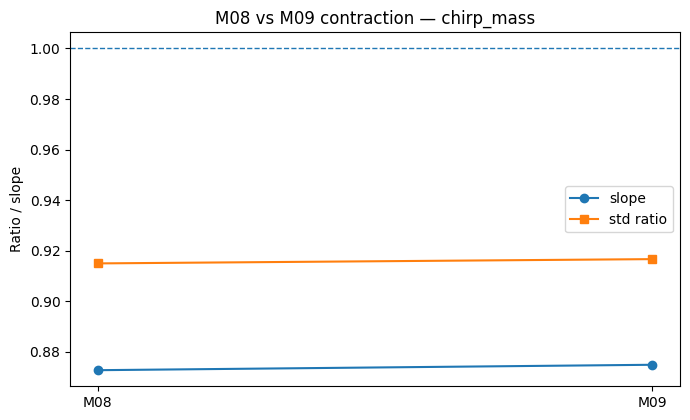

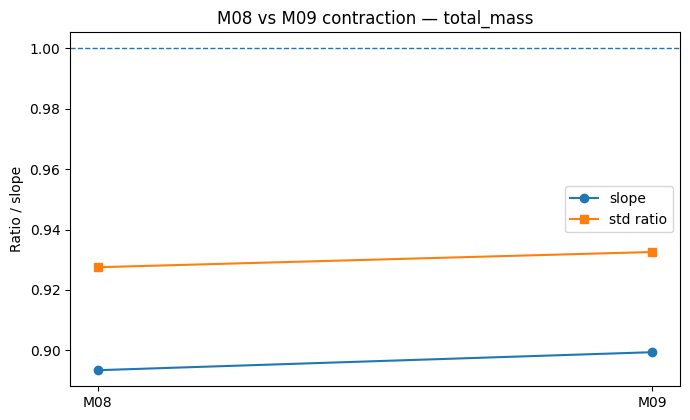

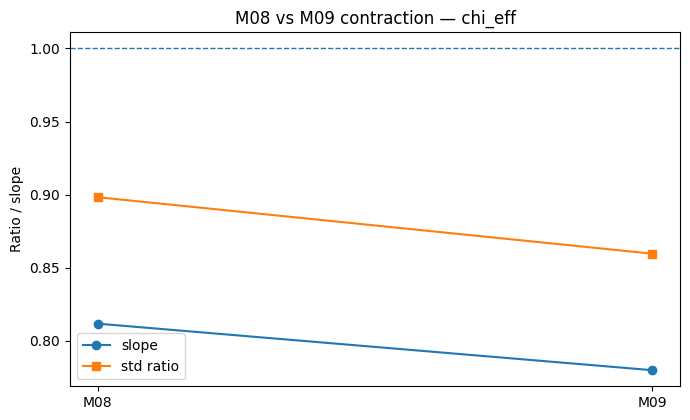

In [9]:
for label in LABEL_NAMES:
    sub = slope_df.query("split == 'test' and label == @label").set_index("run_id").loc[["M08", "M09"]]

    plt.figure(figsize=(7.0, 4.3))
    plt.plot(sub.index, sub["slope"], marker="o", label="slope")
    plt.plot(sub.index, sub["std_ratio_pred_over_true"], marker="s", label="std ratio")
    plt.axhline(1.0, linestyle="--", linewidth=1)
    plt.ylabel("Ratio / slope")
    plt.title(f"M08 vs M09 contraction — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 8. Physical absolute-error quantiles

In [10]:
QUANTILES = [0.50, 0.90, 0.95, 0.99]
quantile_rows = []

for split in SPLITS:
    y_true_phys = inverse_standardize(ALIGNED[split]["M08"]["y"])

    for run_id in RUNS:
        pred_phys = inverse_standardize(ALIGNED[split][run_id]["pred"])
        ae = np.abs(pred_phys - y_true_phys)

        for j, label in enumerate(LABEL_NAMES):
            for q in QUANTILES:
                quantile_rows.append({
                    "run_id": run_id,
                    "split": split,
                    "label": label,
                    "quantile": q,
                    "absolute_error": float(np.quantile(ae[:, j], q)),
                })

quantiles_df = pd.DataFrame(quantile_rows)

test_quantile_df = (
    quantiles_df.query("split == 'test'")
    .pivot_table(index=["label", "quantile"], columns="run_id", values="absolute_error")
    .reset_index()
)

test_quantile_df["M09_vs_M08_pct"] = 100 * (test_quantile_df["M09"] - test_quantile_df["M08"]) / test_quantile_df["M08"]

display(test_quantile_df)

run_id,label,quantile,M08,M09,M09_vs_M08_pct
0,chi_eff,0.500000,0.111028,0.110826,-0.181302
1,chi_eff,0.900000,0.300427,0.298029,-0.798206
2,chi_eff,0.950000,0.379371,0.373106,-1.651254
3,chi_eff,0.990000,0.566387,0.568263,0.331110
4,chirp_mass,0.500000,2.335467,2.245406,-3.856213
5,chirp_mass,0.900000,8.031778,7.910862,-1.505463
6,chirp_mass,0.950000,10.439767,10.372705,-0.642370
7,chirp_mass,0.990000,17.008786,16.945677,-0.371035
8,total_mass,0.500000,5.300006,5.121672,-3.364790
9,total_mass,0.900000,15.019311,14.824495,-1.297106


## 9. Paired bootstrap on test-set metric deltas

In [11]:
def paired_bootstrap_metric_delta(y_true, pred_a, pred_b, metric="mse", n_boot=2000, seed=123):
    rng = np.random.default_rng(seed)
    n = y_true.shape[0]
    n_labels = y_true.shape[1]

    deltas = np.empty((n_boot, n_labels), dtype=float)

    err_a = pred_a - y_true
    err_b = pred_b - y_true

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)

        if metric == "mse":
            va = np.mean(err_a[idx] ** 2, axis=0)
            vb = np.mean(err_b[idx] ** 2, axis=0)
        elif metric == "mae":
            va = np.mean(np.abs(err_a[idx]), axis=0)
            vb = np.mean(np.abs(err_b[idx]), axis=0)
        else:
            raise ValueError(metric)

        deltas[i] = vb - va

    return deltas


y_true_test = ALIGNED["test"]["M08"]["y"]
pred_m08_test = ALIGNED["test"]["M08"]["pred"]
pred_m09_test = ALIGNED["test"]["M09"]["pred"]

bootstrap_rows = []

for metric in ["mse", "mae"]:
    deltas = paired_bootstrap_metric_delta(y_true_test, pred_m08_test, pred_m09_test, metric=metric, n_boot=2000, seed=123)

    if metric == "mse":
        point = np.mean((pred_m09_test - y_true_test) ** 2, axis=0) - np.mean((pred_m08_test - y_true_test) ** 2, axis=0)
    else:
        point = np.mean(np.abs(pred_m09_test - y_true_test), axis=0) - np.mean(np.abs(pred_m08_test - y_true_test), axis=0)

    for j, label in enumerate(LABEL_NAMES):
        bootstrap_rows.append({
            "metric": metric.upper(),
            "label": label,
            "delta_M09_minus_M08": float(point[j]),
            "ci95_low": float(np.quantile(deltas[:, j], 0.025)),
            "ci95_high": float(np.quantile(deltas[:, j], 0.975)),
            "prob_delta_below_zero": float(np.mean(deltas[:, j] < 0)),
        })

bootstrap_df = pd.DataFrame(bootstrap_rows)
display(bootstrap_df)

,metric,label,delta_M09_minus_M08,ci95_low,ci95_high,prob_delta_below_zero
0,MSE,chirp_mass,-0.001243,-0.002538,-0.000020,0.976500
1,MSE,total_mass,-0.002725,-0.003826,-0.001629,1.000000
2,MSE,chi_eff,-0.004137,-0.006629,-0.001577,0.998500
3,MAE,chirp_mass,-0.003224,-0.004435,-0.001961,1.000000
4,MAE,total_mass,-0.005053,-0.006291,-0.003861,1.000000
5,MAE,chi_eff,-0.002272,-0.004282,-0.000192,0.985000


## 10. Per-event win rates and disagreement

In [12]:
ae_m08 = np.abs(pred_m08_test - y_true_test)
ae_m09 = np.abs(pred_m09_test - y_true_test)

win_rows = []
for j, label in enumerate(LABEL_NAMES):
    disagreement = pred_m09_test[:, j] - pred_m08_test[:, j]

    win_rows.append({
        "label": label,
        "M08_win_rate": float(np.mean(ae_m08[:, j] < ae_m09[:, j])),
        "M09_win_rate": float(np.mean(ae_m09[:, j] < ae_m08[:, j])),
        "tie_rate": float(np.mean(ae_m08[:, j] == ae_m09[:, j])),
        "prediction_difference_mean": float(np.mean(disagreement)),
        "prediction_difference_std": float(np.std(disagreement)),
        "prediction_difference_q95_abs": float(np.quantile(np.abs(disagreement), 0.95)),
    })

win_rate_df = pd.DataFrame(win_rows)
display(win_rate_df)

,label,M08_win_rate,M09_win_rate,tie_rate,prediction_difference_mean,prediction_difference_std,prediction_difference_q95_abs
0,chirp_mass,0.487800,0.512200,0.000000,0.006305,0.120346,0.240781
1,total_mass,0.478067,0.521933,0.000000,0.005830,0.119649,0.239866
2,chi_eff,0.497867,0.502133,0.000000,0.026496,0.202344,0.401207


## 11. Training histories and checkpoint metadata

bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz ['epoch_time', 'train_loss', 'train_time', 'val_loss', 'val_time']
bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_sd32_emb64_d124_bs256_MSELoss_seed123_history.npz ['epoch_time', 'train_loss', 'train_time', 'val_loss', 'val_time']


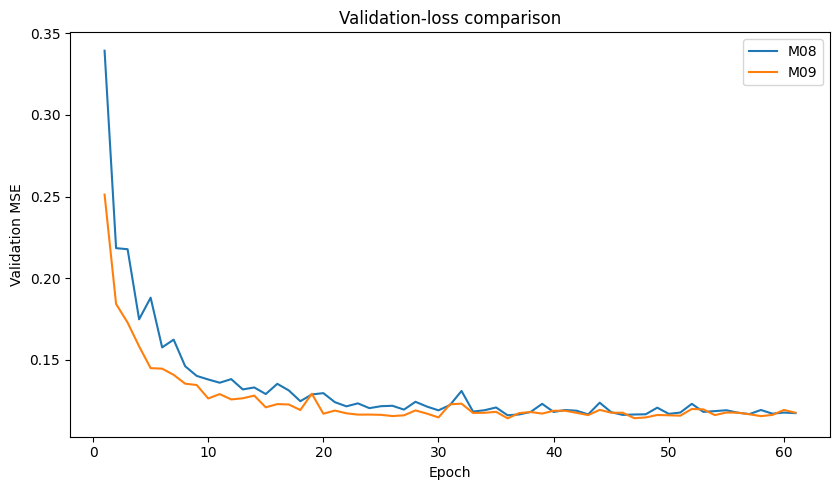

,run_id,best_epoch,stop_epoch,best_val_loss,final_train_loss,final_val_loss
0,M08,36,61,0.116116,0.108771,0.117426
1,M09,36,61,0.114245,0.097939,0.117672


In [13]:
def load_history(path):
    with np.load(path, allow_pickle=True) as data:
        out = {key: np.asarray(data[key]) for key in data.files}
    print(path.name, sorted(out))
    return out


def first_existing(mapping, candidates):
    for key in candidates:
        if key in mapping:
            return np.asarray(mapping[key])
    return None


HISTORIES = {run_id: load_history(run["history_path"]) for run_id, run in RUNS.items()}

history_rows = []

plt.figure(figsize=(8.5, 5.0))

for run_id, history in HISTORIES.items():
    train_loss = first_existing(history, ["train_loss", "train_losses", "loss_train"])
    val_loss = first_existing(history, ["val_loss", "val_losses", "loss_val"])

    if train_loss is None or val_loss is None:
        print(f"Missing loss keys for {run_id}")
        continue

    best_idx = int(np.nanargmin(val_loss))
    best_epoch = best_idx + 1
    stop_epoch = len(val_loss)

    history_rows.append({
        "run_id": run_id,
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "best_val_loss": float(val_loss[best_idx]),
        "final_train_loss": float(train_loss[-1]),
        "final_val_loss": float(val_loss[-1]),
    })

    epochs = np.arange(1, len(val_loss) + 1)
    plt.plot(epochs, val_loss, label=run_id)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation-loss comparison")
plt.legend()
plt.tight_layout()
plt.show()

history_summary_df = pd.DataFrame(history_rows)
display(history_summary_df)

In [14]:
checkpoint_rows = []

try:
    import torch

    for run_id, run in RUNS.items():
        checkpoint = torch.load(run["checkpoint_path"], map_location="cpu")

        model_config = checkpoint.get("model_config", {})
        model_kwargs = (
            model_config.get("kwargs")
            or model_config.get("model_kwargs")
            or checkpoint.get("model_kwargs")
            or {}
        )

        checkpoint_rows.append({
            "run_id": run_id,
            "checkpoint_name": run["checkpoint_path"].name,
            "saved_epoch": checkpoint.get("epoch", np.nan),
            "best_val_loss": checkpoint.get("best_val_loss", np.nan),
            "architecture": model_config.get("architecture"),
            "class_name": model_config.get("class_name"),
            "training_seed": model_config.get("training_seed", checkpoint.get("training_seed")),
            "split_seed": model_config.get("split_seed", checkpoint.get("split_seed")),
            "dilations": model_kwargs.get("dilations"),
            "embedding_dim": model_kwargs.get("embedding_dim"),
            "attention_slots": model_kwargs.get("attention_slots"),
            "attention_hidden": model_kwargs.get("attention_hidden"),
            "attention_dropout": model_kwargs.get("attention_dropout"),
            "slot_dim": model_kwargs.get("slot_dim"),
        })

    checkpoint_df = pd.DataFrame(checkpoint_rows)
    display(checkpoint_df)

except Exception as exc:
    print("Checkpoint inspection skipped or failed:")
    print(type(exc).__name__, exc)
    checkpoint_df = pd.DataFrame()

,run_id,checkpoint_name,saved_epoch,best_val_loss,architecture,class_name,training_seed,split_seed,dilations,embedding_dim,attention_slots,attention_hidden,attention_dropout,slot_dim
0,M08,bbh_processed_4s_seobnrv4opt_snr10-25_n500_000...,36,0.116116,SimpleCNN_ResidualDilated,SimpleCNN_ResidualDilated,123,123,"[1, 2, 4]",64,NaN,NaN,NaN,NaN
1,M09,bbh_processed_4s_seobnrv4opt_snr10-25_n500_000...,36,0.114245,M09_multiattn_k4_sd32_emb64_d124,SimpleCNN_ResidualDilatedMultiAttention,123,123,"[1, 2, 4]",64,4.000000,64.000000,0.000000,32.000000


## 12. Optional attention-map diagnostic

This section requires access to the HDF5 dataset and the M09 checkpoint/model class. It is disabled by default. Enable it only after the metric comparison.

In [15]:
RUN_ATTENTION_DIAGNOSTIC = False

if RUN_ATTENTION_DIAGNOSTIC:
    import h5py
    import torch
    from src.models.network import SimpleCNN_ResidualDilatedMultiAttention

    dataset_path = PROCESSED_ROOT / f"{DATASET_ID}.h5"
    assert dataset_path.exists(), dataset_path

    m09_checkpoint = torch.load(RUNS["M09"]["checkpoint_path"], map_location="cpu")
    m09_model_config = m09_checkpoint.get("model_config", {})
    m09_kwargs = m09_model_config.get("model_kwargs", {})

    # Fallbacks if checkpoint metadata is incomplete.
    m09_kwargs.setdefault("n_detectors", 3)
    m09_kwargs.setdefault("n_outputs", 3)
    m09_kwargs.setdefault("embedding_dim", 64)
    m09_kwargs.setdefault("residual_channels", 64)
    m09_kwargs.setdefault("dilations", [1, 2, 4])
    m09_kwargs.setdefault("residual_kernel_size", 7)
    m09_kwargs.setdefault("dropout_conv", 0.05)
    m09_kwargs.setdefault("dropout_dense", 0.1)
    m09_kwargs.setdefault("num_groups", 8)
    m09_kwargs.setdefault("attention_slots", 4)
    m09_kwargs.setdefault("attention_hidden", 64)
    m09_kwargs.setdefault("attention_dropout", 0.0)
    m09_kwargs.setdefault("slot_dim", 32)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SimpleCNN_ResidualDilatedMultiAttention(**m09_kwargs).to(device)
    model.load_state_dict(m09_checkpoint["model_state_dict"])
    model.eval()

    idx_test = ALIGNED["test"]["M09"]["idx"]
    rng = np.random.default_rng(123)
    selected_positions = rng.choice(len(idx_test), size=6, replace=False)
    selected_hdf5_idx = idx_test[selected_positions]

    with h5py.File(dataset_path, "r") as f:
        X = np.asarray(f["X"][np.sort(selected_hdf5_idx)], dtype=np.float32)

    x = torch.from_numpy(X).to(device)

    with torch.no_grad():
        features, attn = model.get_attention_weights(x)
        attn = attn.detach().cpu().numpy()

    for i, sample_idx in enumerate(selected_hdf5_idx):
        plt.figure(figsize=(8.5, 4.0))
        for k in range(attn.shape[1]):
            plt.plot(attn[i, k], label=f"slot {k}")
        plt.xlabel("Encoder time index")
        plt.ylabel("Attention weight")
        plt.title(f"M09 attention windows — HDF5 idx {sample_idx}")
        plt.legend()
        plt.tight_layout()
        plt.show()

else:
    print("Attention diagnostic disabled. Set RUN_ATTENTION_DIAGNOSTIC = False to run it.")

Attention diagnostic disabled. Set RUN_ATTENTION_DIAGNOSTIC = False to run it.


## 13. Decision table

In [16]:
decision_rows = []

for label in LABEL_NAMES:
    metric_row = test_difference_df.set_index("label").loc[label]
    slope_row = slope_delta_df.set_index("label").loc[label]

    q95 = test_quantile_df.query("label == @label and quantile == 0.95").iloc[0]
    q99 = test_quantile_df.query("label == @label and quantile == 0.99").iloc[0]

    boot_mse = bootstrap_df.query("label == @label and metric == 'MSE'").iloc[0]
    boot_mae = bootstrap_df.query("label == @label and metric == 'MAE'").iloc[0]

    decision_rows.append({
        "label": label,
        "MSE_delta_pct": metric_row["MSE_delta_pct"],
        "MAE_delta_pct": metric_row["MAE_delta_pct"],
        "R2_delta": metric_row["R2_delta"],
        "slope_delta": slope_row["slope_delta"],
        "std_ratio_delta": slope_row["std_ratio_delta"],
        "q95_abs_error_delta_pct": q95["M09_vs_M08_pct"],
        "q99_abs_error_delta_pct": q99["M09_vs_M08_pct"],
        "M09_win_rate": win_rate_df.set_index("label").loc[label, "M09_win_rate"],
        "bootstrap_MSE_ci95_low": boot_mse["ci95_low"],
        "bootstrap_MSE_ci95_high": boot_mse["ci95_high"],
        "bootstrap_MAE_ci95_low": boot_mae["ci95_low"],
        "bootstrap_MAE_ci95_high": boot_mae["ci95_high"],
    })

decision_df = pd.DataFrame(decision_rows)

display(global_difference_df)
display(decision_df)

,global_MSE_M08,global_MSE_M09,global_MSE_delta_pct,global_MAE_M08,global_MAE_M09,global_MAE_delta_pct
0,0.116352,0.113651,-2.321867,0.244785,0.241269,-1.436609


,label,MSE_delta_pct,MAE_delta_pct,R2_delta,slope_delta,std_ratio_delta,q95_abs_error_delta_pct,q99_abs_error_delta_pct,M09_win_rate,bootstrap_MSE_ci95_low,bootstrap_MSE_ci95_high,bootstrap_MAE_ci95_low,bootstrap_MAE_ci95_high
0,chirp_mass,-1.347565,-1.525661,0.001236,0.002141,0.001692,-0.642370,-0.371035,0.512200,-0.002538,-0.000020,-0.004435,-0.001961
1,total_mass,-3.687344,-2.513063,0.002720,0.005962,0.005041,-1.185166,-0.330339,0.521933,-0.003826,-0.001629,-0.006291,-0.003861
2,chi_eff,-2.261583,-0.705827,0.004147,-0.031817,-0.038600,-1.651254,0.331110,0.502133,-0.006629,-0.001577,-0.004282,-0.000192


## 14. Save tables

In [17]:
OUTPUT_DIR = RESULTS_ROOT / "evaluation_M08_vs_M09"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables = {
    "metrics_all.csv": metrics_df,
    "global_metrics.csv": global_metrics_df,
    "test_differences.csv": test_difference_df,
    "global_test_difference.csv": global_difference_df,
    "slope_diagnostics.csv": slope_df,
    "slope_deltas.csv": slope_delta_df,
    "absolute_error_quantiles.csv": quantiles_df,
    "test_quantile_differences.csv": test_quantile_df,
    "paired_bootstrap.csv": bootstrap_df,
    "win_rates_and_disagreement.csv": win_rate_df,
    "training_summary.csv": history_summary_df,
    "decision_table.csv": decision_df,
}

if not checkpoint_df.empty:
    tables["checkpoint_metadata.csv"] = checkpoint_df

for filename, dataframe in tables.items():
    path = OUTPUT_DIR / filename
    dataframe.to_csv(path, index=False)
    print("Saved:", path)

Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/metrics_all.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/global_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/test_differences.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/global_test_difference.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/slope_diagnostics.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/slope_deltas.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/absolute_error_quantiles.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/test_quantile_differences.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/paired_bootstrap.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/win_rates_and_disagreement.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/training_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/

## 15. True-vs-predicted density plots

These plots show the test-set density in physical units. The diagonal corresponds to perfect prediction.

Use them to inspect:

- regression to the mean;
- compression at the high/low ends of the parameter range;
- whether M09 changes the shape of the prediction cloud relative to M08;
- whether small metric gains correspond to visible structural improvements.


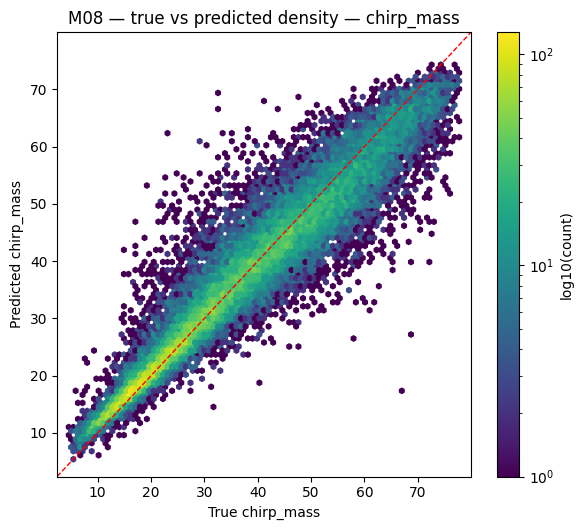

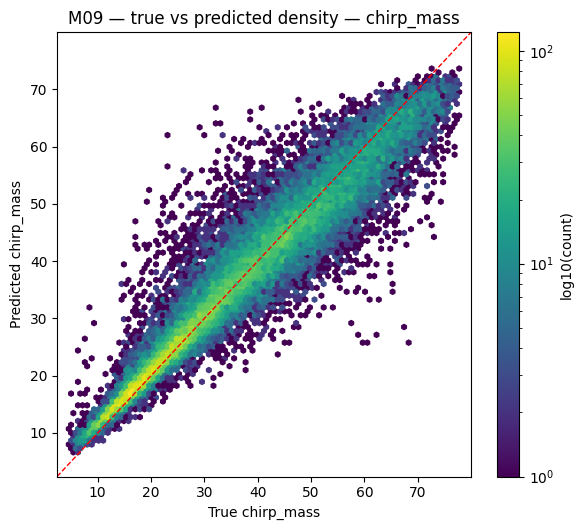

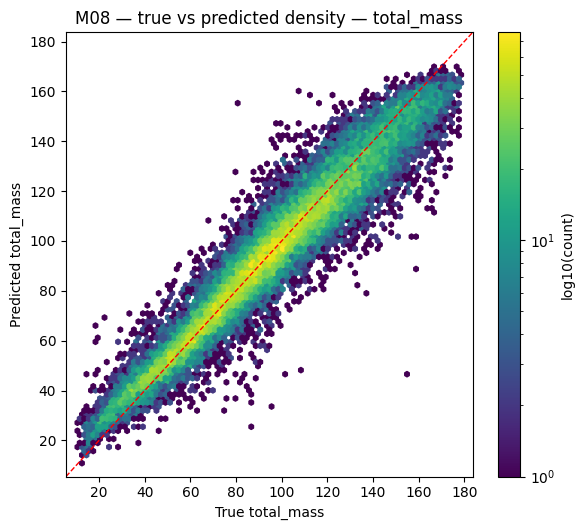

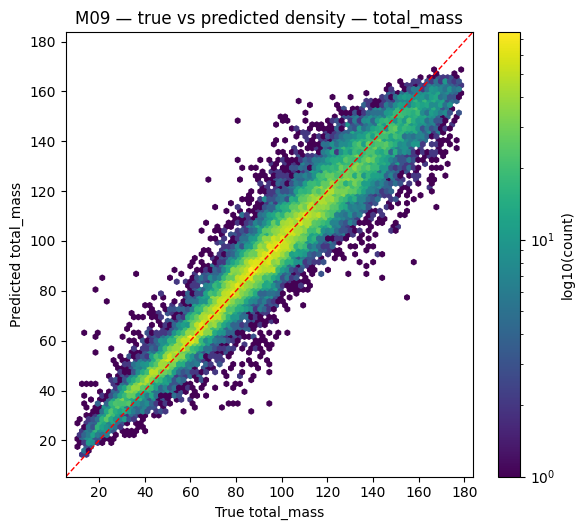

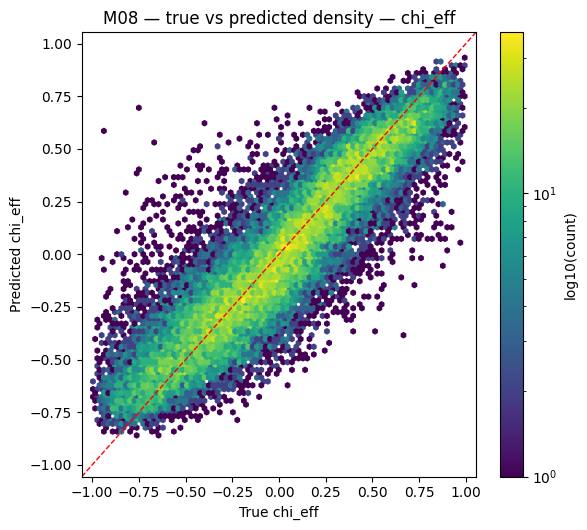

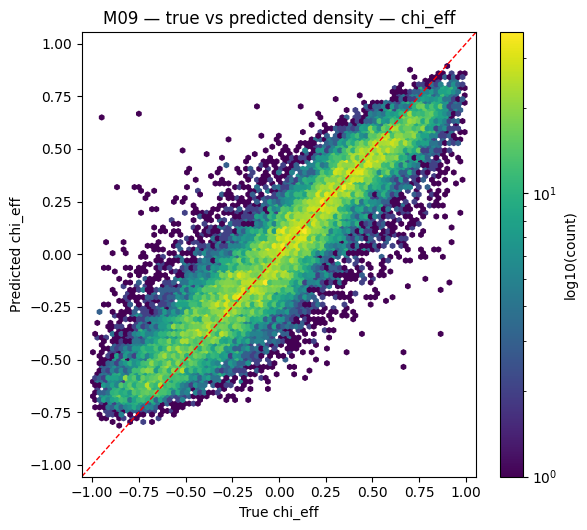

In [18]:
def plot_true_pred_density(
    y_true,
    y_pred,
    label,
    model_name,
    gridsize=80,
    mincnt=1,
):
    j = LABEL_NAMES.index(label)

    true = y_true[:, j]
    pred = y_pred[:, j]

    lo = min(np.min(true), np.min(pred))
    hi = max(np.max(true), np.max(pred))
    pad = 0.03 * (hi - lo)
    lo -= pad
    hi += pad

    plt.figure(figsize=(6.0, 5.4))
    hb = plt.hexbin(
        true,
        pred,
        gridsize=gridsize,
        mincnt=mincnt,
        bins="log",
    )
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color = "red")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.xlabel(f"True {label}")
    plt.ylabel(f"Predicted {label}")
    plt.title(f"{model_name} — true vs predicted density — {label}")
    plt.colorbar(hb, label="log10(count)")
    plt.tight_layout()
    plt.show()


y_true_test_phys = inverse_standardize(ALIGNED["test"]["M08"]["y"])

for label in LABEL_NAMES:
    for run_id in ["M08", "M09"]:
        y_pred_test_phys = inverse_standardize(ALIGNED["test"][run_id]["pred"])
        plot_true_pred_density(
            y_true=y_true_test_phys,
            y_pred=y_pred_test_phys,
            label=label,
            model_name=run_id,
            gridsize=85,
            mincnt=1,
        )


## 16. Residual density plots: pred - true vs true

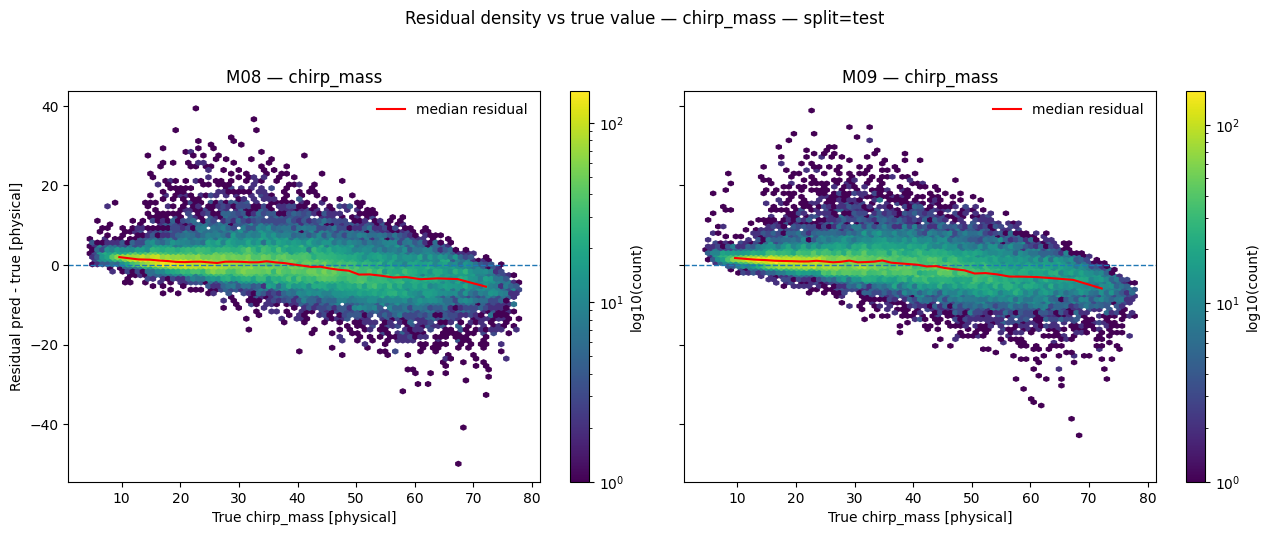

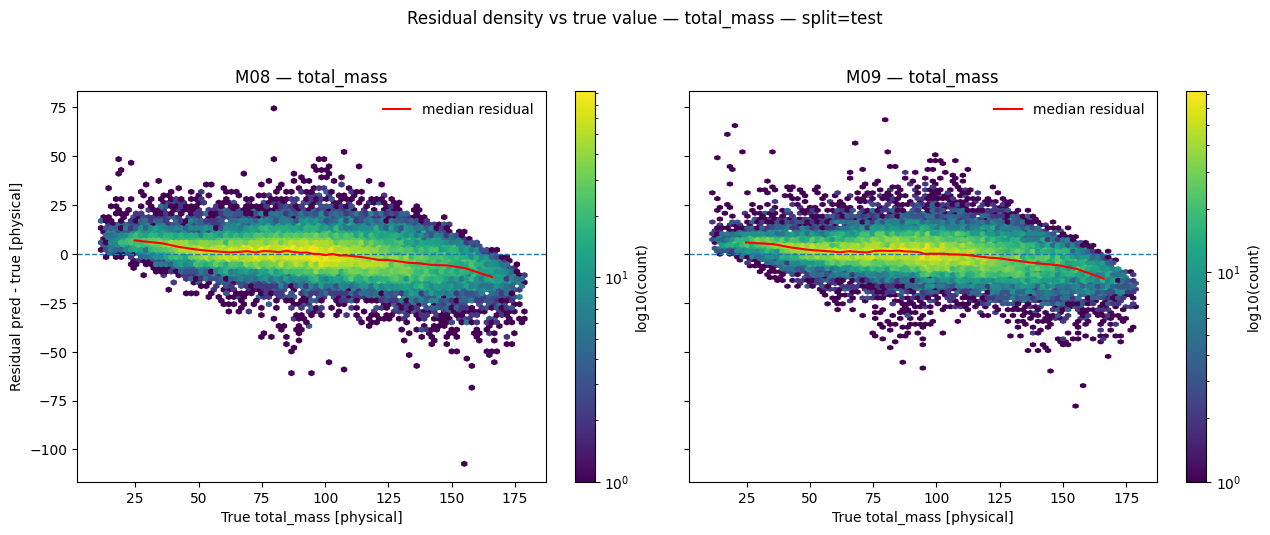

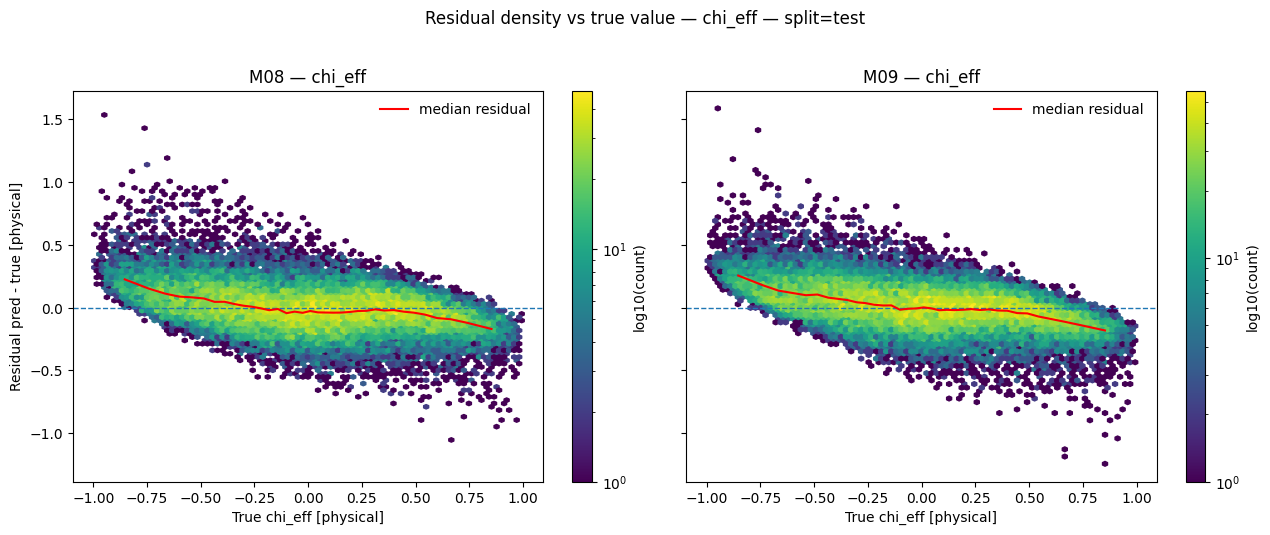

In [19]:


def plot_residual_density_by_true(
    run_ids=("M08", "M09"),
    split="test",
    physical_space=True,
    gridsize=80,
    trend_bins=35,
    mincnt=1,
):
    """
    Plot residual density:
        residual = prediction - truth
    against true physical/standardized target value.

    Interpretation
    --------------
    - y = 0 means no bias.
    - residual > 0 means overprediction.
    - residual < 0 means underprediction.
    - A sloped median residual curve indicates regression-to-the-mean.
    """

    for label_idx, label in enumerate(LABEL_NAMES):
        fig, axes = plt.subplots(
            1,
            len(run_ids),
            figsize=(6.5 * len(run_ids), 5.2),
            sharey=True,
        )

        if len(run_ids) == 1:
            axes = [axes]

        for ax, run_id in zip(axes, run_ids):
            y_true_std = ALIGNED[split][run_id]["y"][:, label_idx]
            y_pred_std = ALIGNED[split][run_id]["pred"][:, label_idx]

            if physical_space:
                y_true = y_true_std * y_std[label_idx] + y_mean[label_idx]
                y_pred = y_pred_std * y_std[label_idx] + y_mean[label_idx]
                unit = "physical"
            else:
                y_true = y_true_std
                y_pred = y_pred_std
                unit = "standardized"

            residual = y_pred - y_true

            hb = ax.hexbin(
                y_true,
                residual,
                gridsize=gridsize,
                bins="log",
                mincnt=mincnt,
            )

            fig.colorbar(
                hb,
                ax=ax,
                label="log10(count)",
            )

            ax.axhline(
                0.0,
                linestyle="--",
                linewidth=1.0,
            )

            # Median residual trend in true-value bins.
            edges = np.quantile(
                y_true,
                np.linspace(0.0, 1.0, trend_bins + 1),
            )
            edges = np.unique(edges)

            centers = []
            medians = []
            q16 = []
            q84 = []

            for left, right in zip(edges[:-1], edges[1:]):
                mask = (y_true >= left) & (y_true <= right)
                if mask.sum() < 20:
                    continue

                centers.append(np.median(y_true[mask]))
                medians.append(np.median(residual[mask]))
                q16.append(np.quantile(residual[mask], 0.16))
                q84.append(np.quantile(residual[mask], 0.84))

            centers = np.asarray(centers)
            medians = np.asarray(medians)
            q16 = np.asarray(q16)
            q84 = np.asarray(q84)

            ax.plot(
                centers,
                medians,
                linewidth=1.5,
                label="median residual",
                color="red"
            )

            # ax.fill_between(
            #     centers,
            #     q16,
            #     q84,
            #     alpha=0.20,
            #     label="16–84%",

            # )

            ax.set_xlabel(f"True {label} [{unit}]")
            ax.set_title(f"{run_id} — {label}")

            if ax is axes[0]:
                ax.set_ylabel(f"Residual pred - true [{unit}]")

            ax.legend(frameon=False)

        fig.suptitle(
            f"Residual density vs true value — {label} — split={split}",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


plot_residual_density_by_true(
    run_ids=("M08", "M09"),
    split="test",
    physical_space=True,
    gridsize=85,
    trend_bins=35,
)

## 17. Compact true-vs-predicted comparison tables

These tables quantify the visual pattern shown above: slope, dispersion ratio, and high-percentile absolute error.

In [20]:
true_pred_summary_cols = [
    "label",
    "slope_M08",
    "slope_M09",
    "slope_delta",
    "std_ratio_M08",
    "std_ratio_M09",
    "std_ratio_delta",
]

display(slope_delta_df[true_pred_summary_cols])

tail_summary = (
    test_quantile_df
    .query("quantile in [0.90, 0.95, 0.99]")
    .copy()
)

display(tail_summary)

,label,slope_M08,slope_M09,slope_delta,std_ratio_M08,std_ratio_M09,std_ratio_delta
0,chirp_mass,0.872785,0.874926,0.002141,0.915003,0.916695,0.001692
1,total_mass,0.893434,0.899396,0.005962,0.927534,0.932575,0.005041
2,chi_eff,0.811833,0.780016,-0.031817,0.898270,0.859670,-0.038600


run_id,label,quantile,M08,M09,M09_vs_M08_pct
1,chi_eff,0.900000,0.300427,0.298029,-0.798206
2,chi_eff,0.950000,0.379371,0.373106,-1.651254
3,chi_eff,0.990000,0.566387,0.568263,0.331110
5,chirp_mass,0.900000,8.031778,7.910862,-1.505463
6,chirp_mass,0.950000,10.439767,10.372705,-0.642370
7,chirp_mass,0.990000,17.008786,16.945677,-0.371035
9,total_mass,0.900000,15.019311,14.824495,-1.297106
10,total_mass,0.950000,19.126154,18.899477,-1.185166
11,total_mass,0.990000,29.286310,29.189566,-0.330339


## 18. Final decision

### Training behavior

M08 and M09 reach their best validation checkpoints at the same epoch, epoch 36, and both stop at epoch 61. M09 obtains a lower best validation loss:

- M08 best validation loss: 0.116116
- M09 best validation loss: 0.114245

This is a relative validation improvement of approximately 1.61%. However, M09 also ends with a lower final training loss than M08 while having a similar final validation loss. This suggests that the attention-pooling model has slightly higher effective capacity, but the validation gain is modest.

### Test performance

On the standardized test set, M09 improves the global metrics relative to M08:

- global MSE: 0.116352 → 0.113651, a 2.32% reduction;
- global MAE: 0.244785 → 0.241269, a 1.44% reduction.

The improvement is present for all three targets:

- chirp mass: MSE −1.35%, MAE −1.53%;
- total mass: MSE −3.69%, MAE −2.51%;
- effective spin: MSE −2.26%, MAE −0.71%.

The paired bootstrap intervals are below zero for all target-level MSE and MAE deltas, so the test-set improvement is statistically detectable under fixed trained models. The strongest target-level improvement is total mass.

However, the gain is small in practical terms. It is also smaller than the seed-to-seed variability observed for M08, where seed124 improved the global MSE by about 3.6% relative to M08 seed123. Therefore, M09 cannot yet be considered a clearly superior architecture from this single seed.

### Regression and contraction

For the mass parameters, M09 slightly improves the regression slopes and prediction dispersion:

- chirp-mass slope: 0.8728 → 0.8749;
- total-mass slope: 0.8934 → 0.8994.

This is favorable but small.

For effective spin, M09 reduces the slope and dispersion:

- chi_eff slope: 0.8118 → 0.7800;
- std(pred)/std(true): 0.8983 → 0.8597.

This is the main warning sign. M09 reduces the chi_eff MSE, but it does so while producing a more compressed prediction distribution. The MAE gain is also small for chi_eff, and the q99 absolute-error quantile slightly worsens. This suggests that M09 may be smoothing or regularizing the effective-spin predictions rather than learning a substantially richer temporal representation.

### Error tails

M09 improves most physical absolute-error quantiles, but the tail improvements are modest:

- chirp mass q95: −0.64%, q99: −0.37%;
- total mass q95: −1.19%, q99: −0.33%;
- chi_eff q95: −1.65%, q99: +0.33%.

Thus, M09 does not produce a strong reduction of difficult-event tails. The q99 degradation for chi_eff is small, but it reinforces the point that the attention pooling is not obviously solving the hardest effective-spin cases.

### Attention-window diagnostic

The attention windows are not completely trivial. The four windows often concentrate on different encoder-time regions, and at least one window frequently forms a sharper peak that may plausibly correspond to the high-information part of the signal, such as the merger/ringdown region.

This is useful diagnostically: the model is using the attention mechanism in a non-uniform way. However, the metric gains indicate that this extra temporal selection is not translating into a large improvement in parameter estimation. A plausible interpretation is that the residual dilated encoder already extracts most of the relevant temporal information before pooling, so replacing average pooling with multi-slot attention only gives a small refinement.

### Adoption decision

M09 should not replace M08 as the operational baseline yet.

The result is best interpreted as a positive but marginal pooling ablation:

1. M09 improves global test MSE and MAE relative to M08 seed123.
2. The improvement is consistent across targets and statistically detectable on the fixed test set.
3. The practical gain is small.
4. The gain is smaller than the previously observed M08 seed-to-seed variability.
5. M09 worsens the effective-spin slope and prediction dispersion.
6. The high-error tails improve only weakly and chi_eff q99 slightly worsens.
7. The attention windows are interpretable, but they do not provide evidence of a major new performance regime.

Therefore, M08 remains the current operational baseline. M09 should be retained as an informative ablation showing that learned temporal pooling can provide a small improvement, especially for total mass, but not enough to justify replacing M08 without additional evidence.

### Recommended next steps

The next priority should not be another pooling variant immediately. The evidence suggests that pooling is not the dominant bottleneck once the residual dilated encoder is in place.

Recommended sequence:

1. Keep M08 as the baseline for the main Mondrian/conformal analysis.
2. Optionally evaluate M09 with Mondrian only after the M08/M00 conformal story is finalized.
3. If M09 is pursued further, run a second seed before making architectural claims.
4. Inspect attention windows in relation to physical quantities: merger location, mass, signal duration, SNR, and residual size.
5. If searching for a larger architecture gain, test a deeper non-causal TCN or a richer residual-dilated encoder rather than more pooling-only variants.

The current conclusion is that M09 is scientifically useful, but not operationally decisive.


## 19. Attention windows and final-X GW-region metadata

This section uses the actual dataset-generation coordinate convention.

The important point is that the HDF5 `injection/<det>/overlap_*_index_strain` fields are **not** in final `X[event, :, :]` coordinates. They are indices in the longer processing-context strain segment used at the injection stage.

The dataset builder does this:

1. Choose the final output segment start time: `placement.segment_start_time`.
2. Build a longer processing-context segment starting at
   `placement.segment_start_time - processing_context_start_seconds`.
3. Inject the windowed projected GW signal into that longer context segment.
4. Process the full context segment.
5. Crop back to the final 4 s output window.

Therefore, to convert injection indices into final-X indices, subtract:

```python
processing_context_start_samples
```

and then intersect with `[0, config.length]`.

The attention indices are encoder indices. For M08/M09, the encoder has three stride-2 convolutional blocks before the residual-dilated stack, so the encoder has about 2049 positions. For visualization we map encoder positions back to approximate original sample coordinates using the strided-convolution centers. This is not a full receptive-field visualization, but it is sufficient for checking whether attention windows lie near the injected GW region.


In [21]:
# ============================================================
# HDF5 metadata discovery and ordered reads
# ============================================================

import h5py
import json
from pathlib import Path

dataset_path = PROCESSED_ROOT / f"{DATASET_ID}.h5"
if not dataset_path.exists():
    dataset_path = PROCESSED_ROOT / DATASET_ID / f"{DATASET_ID}.h5"

assert dataset_path.exists(), dataset_path

print("dataset_path:", dataset_path)

def discover_hdf5_datasets(h5_path):
    rows = []
    with h5py.File(h5_path, "r") as f:
        n_samples = f["X"].shape[0]

        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                shape = tuple(obj.shape)
                event_level = len(shape) > 0 and shape[0] == n_samples
                rows.append({
                    "path": name,
                    "shape": shape,
                    "dtype": str(obj.dtype),
                    "event_level": event_level,
                    "ndim": len(shape),
                })

        f.visititems(visitor)

    return pd.DataFrame(rows).sort_values("path").reset_index(drop=True)


metadata_fields_df = discover_hdf5_datasets(dataset_path)

useful_event_fields_df = metadata_fields_df[
    metadata_fields_df["event_level"]
    & metadata_fields_df["path"].str.contains(
        "injection|placement|projection|windowing|snr|parameters",
        regex=True,
    )
].copy()

display(useful_event_fields_df)


def read_hdf5_dataset_preserve_order(
    h5_file,
    dataset_key,
    indices,
    dtype=None,
):
    """
    h5py requires fancy indices to be increasing. This helper reads sorted
    indices and restores the original requested order.
    """
    indices = np.asarray(indices, dtype=np.int64)

    order = np.argsort(indices, kind="stable")
    sorted_indices = indices[order]

    data_sorted = np.asarray(
        h5_file[dataset_key][sorted_indices],
        dtype=dtype,
    )

    inverse_order = np.empty_like(order)
    inverse_order[order] = np.arange(len(order))

    return data_sorted[inverse_order]


def read_event_metadata(
    h5_path,
    hdf5_indices,
    field_paths=None,
    max_vector_width=8,
):
    hdf5_indices = np.asarray(hdf5_indices, dtype=np.int64)
    columns = {"hdf5_index": hdf5_indices}

    with h5py.File(h5_path, "r") as f:
        n_samples = f["X"].shape[0]

        if field_paths is None:
            field_paths = []
            for _, meta_row in metadata_fields_df.iterrows():
                path = meta_row["path"]
                shape = tuple(meta_row["shape"])
                event_level = bool(meta_row["event_level"])
                ndim = int(meta_row["ndim"])

                if not event_level:
                    continue

                if ndim == 1:
                    field_paths.append(path)
                elif ndim == 2 and len(shape) > 1 and shape[1] <= max_vector_width:
                    field_paths.append(path)

        for path in field_paths:
            if path not in f:
                continue

            obj = f[path]
            if len(obj.shape) == 0 or obj.shape[0] != n_samples:
                continue

            values = read_hdf5_dataset_preserve_order(
                h5_file=f,
                dataset_key=path,
                indices=hdf5_indices,
            )

            if values.ndim == 1:
                columns[path] = values
            elif values.ndim == 2 and values.shape[1] <= max_vector_width:
                for j in range(values.shape[1]):
                    columns[f"{path}[{j}]"] = values[:, j]

    return pd.DataFrame(columns)


def find_metadata_jsons():
    candidates = []
    roots = [
        PROCESSED_ROOT,
        PROCESSED_ROOT / DATASET_ID,
        DATA_ROOT,
    ]
    names = [
        f"{DATASET_ID}.metadata.json",
        f"{DATASET_ID}_splits_train400000_val40000_cal30000_test30000_seed123.metadata.json",
        f"{DATASET_ID}_splits_train400000_val40000_cal30000_test30000_seed123.metadata",
    ]

    for root in roots:
        if not root.exists():
            continue
        for name in names:
            p = root / name
            if p.exists():
                candidates.append(p)
        candidates.extend(root.glob(f"{DATASET_ID}*metadata*.json"))
        candidates.extend(root.glob(f"{DATASET_ID}*metadata"))

    return sorted(set(candidates))


metadata_json_candidates = find_metadata_jsons()
print("\nMetadata JSON candidates:")
for p in metadata_json_candidates:
    print(" ", p)


dataset_path: /data/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000.h5


,path,shape,dtype,event_level,ndim
4,injection/H1/is_partially_clipped,"(500000,)",bool,True,1
5,injection/H1/n_clipped_after,"(500000,)",int64,True,1
6,injection/H1/n_clipped_before,"(500000,)",int64,True,1
7,injection/H1/n_injected_samples,"(500000,)",int64,True,1
8,injection/H1/n_signal_samples,"(500000,)",int64,True,1
...,...,...,...,...,...
104,windowing/seconds_before_network_end_in_window,"(500000,)",float64,True,1
105,windowing/segment_duration,"(500000,)",float64,True,1
106,windowing/used_window_duration,"(500000,)",float64,True,1
107,windowing/used_window_end_time,"(500000,)",float64,True,1



Metadata JSON candidates:
  /data/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000.metadata.json
  /data/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_splits_train400000_val40000_cal30000_test30000_seed123.metadata.json


## 20. Correct GW-region mapping into final X coordinates

The real visible GW span in the final input window is computed as:

```python
context_start = processing_context_start_samples
context_end = context_start + final_signal_length

visible_start = max(overlap_start_index_strain, context_start) - context_start
visible_end   = min(overlap_end_index_strain, context_end) - context_start
```

This is done per detector and then combined into a network union.

Do not use `overlap_*_index_signal` for plotting on `X`; those indices refer to the local generated signal array, not the final model input. Do not use raw `overlap_*_index_strain` directly either; those indices are relative to the longer processing-context segment.


In [22]:
# ============================================================
# Correct GW-region inference in final-X coordinates
# ============================================================

DETECTORS = ["H1", "L1", "V1"]
FS = 4096.0


def _float_or_nan(value):
    try:
        return float(value)
    except Exception:
        return np.nan


def _get_processing_context_start_samples(h5_path):
    """
    Number of samples between the processing-context segment start and
    the final model-output segment start.

    This is the offset that must be subtracted from
    injection/*/overlap_*_index_strain to map into final X coordinates.
    """
    with h5py.File(h5_path, "r") as f:
        if "processing_context_start_samples" in f.attrs:
            return int(f.attrs["processing_context_start_samples"])

        # Fallback from seconds if needed.
        if "processing_context_start_seconds" in f.attrs:
            fs = float(f.attrs.get("sampling_frequency", FS))
            return int(round(float(f.attrs["processing_context_start_seconds"]) * fs))

    # Last fallback for the known 500k config.
    return 1664


PROCESSING_CONTEXT_START_SAMPLES = _get_processing_context_start_samples(dataset_path)
print("PROCESSING_CONTEXT_START_SAMPLES:", PROCESSING_CONTEXT_START_SAMPLES)


def _valid_visible_span(start, end, signal_length):
    start = _float_or_nan(start)
    end = _float_or_nan(end)

    if not np.isfinite(start) or not np.isfinite(end):
        return False
    if end <= start:
        return False
    if end <= 0 or start >= signal_length:
        return False
    return True


def _clip_visible_span(start, end, signal_length):
    start = int(np.floor(max(0, start)))
    end = int(np.ceil(min(signal_length, end)))
    return start, end


def _union_spans(spans, source):
    spans = [s for s in spans if s is not None]
    if not spans:
        return None

    return {
        "source": source,
        "start": min(s["start"] for s in spans),
        "end": max(s["end"] for s in spans),
        "width": max(s["end"] for s in spans) - min(s["start"] for s in spans),
        "detector_spans": spans,
    }


def final_x_signal_span_from_context_injection(
    row,
    signal_length,
    context_start_samples=PROCESSING_CONTEXT_START_SAMPLES,
):
    """
    Convert injection overlap indices into final X coordinates.

    injection/<det>/overlap_*_index_strain is measured in the longer
    processing-context segment. Final X starts at context_start_samples.

    Returns the detector-union span in final-X sample coordinates.
    """
    context_start = int(context_start_samples)
    context_end = context_start + int(signal_length)

    spans = []

    for det in DETECTORS:
        sk = f"injection/{det}/overlap_start_index_strain"
        ek = f"injection/{det}/overlap_end_index_strain"

        if sk not in row.index or ek not in row.index:
            continue

        raw_start = _float_or_nan(row[sk])
        raw_end = _float_or_nan(row[ek])

        if not np.isfinite(raw_start) or not np.isfinite(raw_end):
            continue

        # Intersect with the final output window inside context coordinates.
        visible_start_context = max(raw_start, context_start)
        visible_end_context = min(raw_end, context_end)

        final_start = visible_start_context - context_start
        final_end = visible_end_context - context_start

        if _valid_visible_span(final_start, final_end, signal_length):
            start, end = _clip_visible_span(final_start, final_end, signal_length)
            spans.append({
                "detector": det,
                "start": start,
                "end": end,
                "raw_context_start": int(raw_start),
                "raw_context_end": int(raw_end),
            })

    return _union_spans(spans, "final_X_from_context_overlap")


def final_x_signal_span_from_times(row, signal_length):
    """
    Independent time-coordinate cross-check.

    Uses signal_start_time/signal_end_time relative to the final output
    start time, placement/segment_start_time.
    """
    if "placement/segment_start_time" not in row.index:
        return None

    output_start_time = _float_or_nan(row["placement/segment_start_time"])
    if not np.isfinite(output_start_time):
        return None

    spans = []

    for det in DETECTORS:
        sk = f"injection/{det}/signal_start_time"
        ek = f"injection/{det}/signal_end_time"

        if sk not in row.index or ek not in row.index:
            continue

        signal_start_time = _float_or_nan(row[sk])
        signal_end_time = _float_or_nan(row[ek])

        if not np.isfinite(signal_start_time) or not np.isfinite(signal_end_time):
            continue

        start = round((signal_start_time - output_start_time) * FS)
        end = round((signal_end_time - output_start_time) * FS)

        if _valid_visible_span(start, end, signal_length):
            start, end = _clip_visible_span(start, end, signal_length)
            spans.append({
                "detector": det,
                "start": start,
                "end": end,
            })

    return _union_spans(spans, "final_X_from_absolute_times")


def infer_final_x_gw_regions(row, signal_length):
    """
    Return the main final-X GW region and a time-based cross-check.
    """
    candidates = []

    main = final_x_signal_span_from_context_injection(row, signal_length)
    if main is not None:
        candidates.append(main)

    by_time = final_x_signal_span_from_times(row, signal_length)
    if by_time is not None:
        candidates.append(by_time)

    return candidates


def gw_region_summary_for_events(event_metadata_table, signal_length=16384):
    rows = []

    for _, row in event_metadata_table.iterrows():
        candidates = infer_final_x_gw_regions(row, signal_length)

        for cand in candidates:
            rows.append({
                "hdf5_index": int(row["hdf5_index"]),
                "source": cand["source"],
                "start": cand["start"],
                "end": cand["end"],
                "width": cand["width"],
            })

    return pd.DataFrame(rows)


# Encoder-index to original-sample grid for the M08/M09 encoder.
def attention_to_signal_grid(attention_weights, signal_length, mapping="conv_centers"):
    """
    Map encoder attention indices to final-X sample coordinates.

    M08/M09 use three ConvBlock layers with kernel_size=16, stride=2,
    padding=8 before the residual-dilated blocks. Residual blocks and the
    1x1 projection preserve temporal length and center locations.
    """
    n_encoder = attention_weights.shape[-1]

    if mapping == "conv_centers":
        # For three stride-2 convs with kernel=16 and padding=8:
        # center_0 = -3.5 samples, jump = 8 samples.
        grid = -3.5 + 8.0 * np.arange(n_encoder)
        return np.clip(grid, 0, signal_length - 1)

    if mapping == "proportional":
        return np.linspace(0, signal_length - 1, n_encoder)

    raise ValueError(f"Unknown mapping: {mapping}")


PROCESSING_CONTEXT_START_SAMPLES: 1664


## 21. Plot attention windows with the corrected final-X GW region

The shaded region now uses `final_X_from_context_overlap`, i.e. the injected projected signal region after subtracting the processing-context offset.

A second candidate, `final_X_from_absolute_times`, is included as a cross-check. In a consistent dataset these two should agree up to rounding by a few samples.


HDF5 idx=26767 | attention peak samples=[924.5, 716.5, 868.5, 996.5]
  GW region final_X_from_context_overlap: 565–1800 width=1235
    detector spans: [('H1', 565, 1758), ('L1', 605, 1798), ('V1', 606, 1800)]
  GW region final_X_from_absolute_times: 565–1800 width=1235


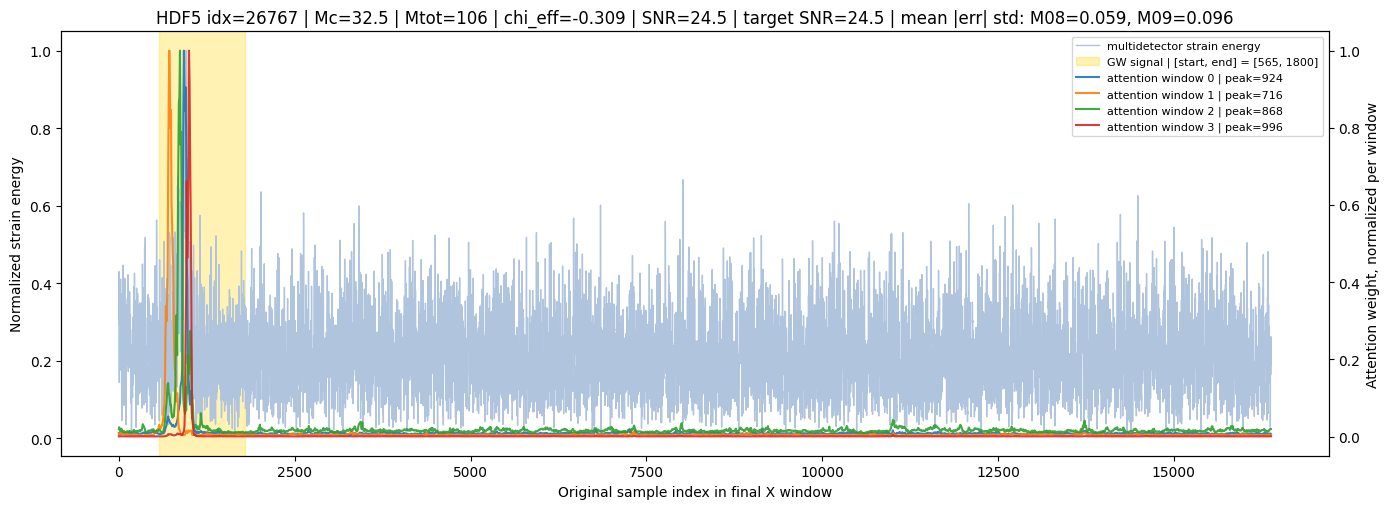

HDF5 idx=294773 | attention peak samples=[9660.5, 9740.5, 8620.5, 9708.5]
  GW region final_X_from_context_overlap: 5003–10062 width=5059
    detector spans: [('H1', 5034, 10062), ('L1', 5003, 10031), ('V1', 5024, 10051)]
  GW region final_X_from_absolute_times: 5003–10062 width=5059


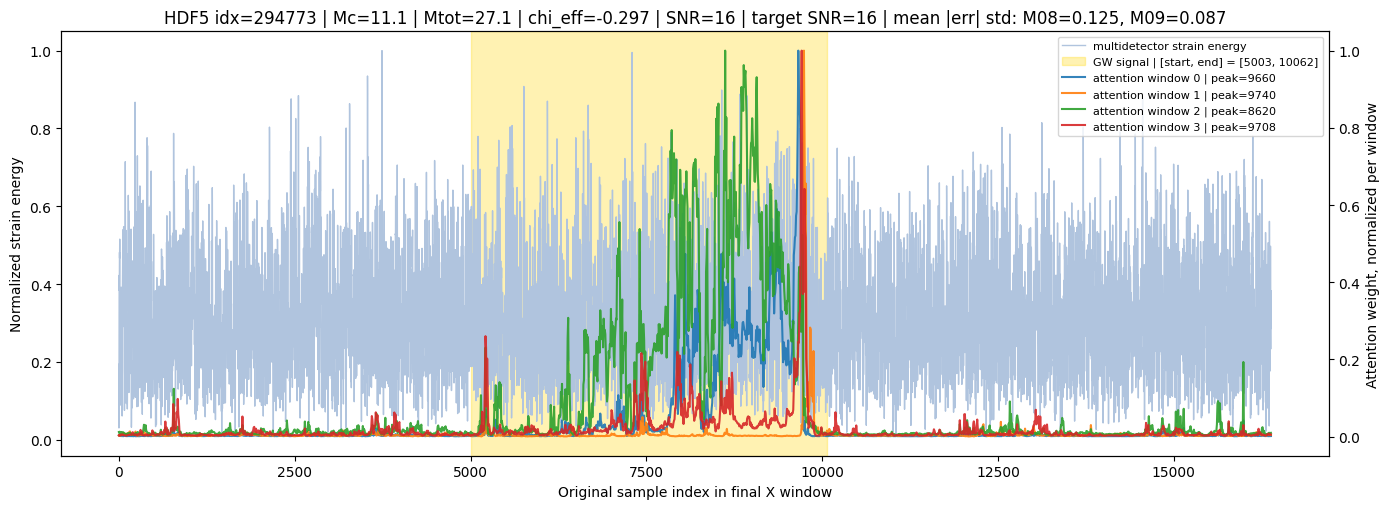

HDF5 idx=454445 | attention peak samples=[5652.5, 5740.5, 5252.5, 5748.5]
  GW region final_X_from_context_overlap: 2781–6165 width=3384
    detector spans: [('H1', 2842, 6165), ('L1', 2827, 6150), ('V1', 2781, 6104)]
  GW region final_X_from_absolute_times: 2781–6165 width=3384


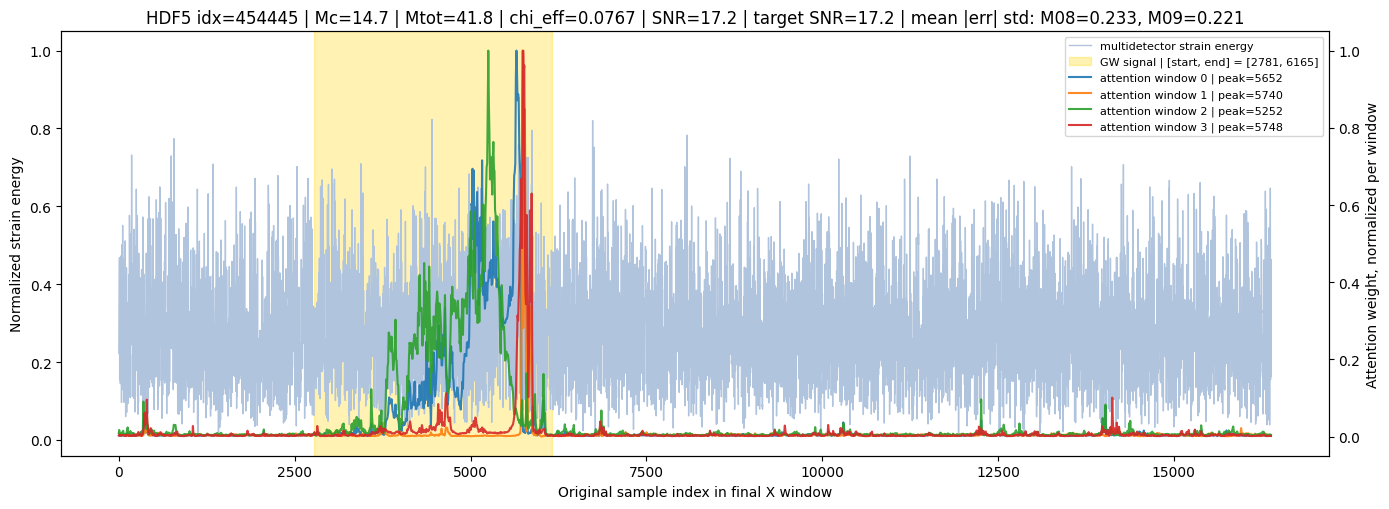

HDF5 idx=108605 | attention peak samples=[8852.5, 8716.5, 8820.5, 8884.5]
  GW region final_X_from_context_overlap: 8547–9831 width=1284
    detector spans: [('H1', 8648, 9831), ('L1', 8626, 9809), ('V1', 8547, 9730)]
  GW region final_X_from_absolute_times: 8547–9831 width=1284


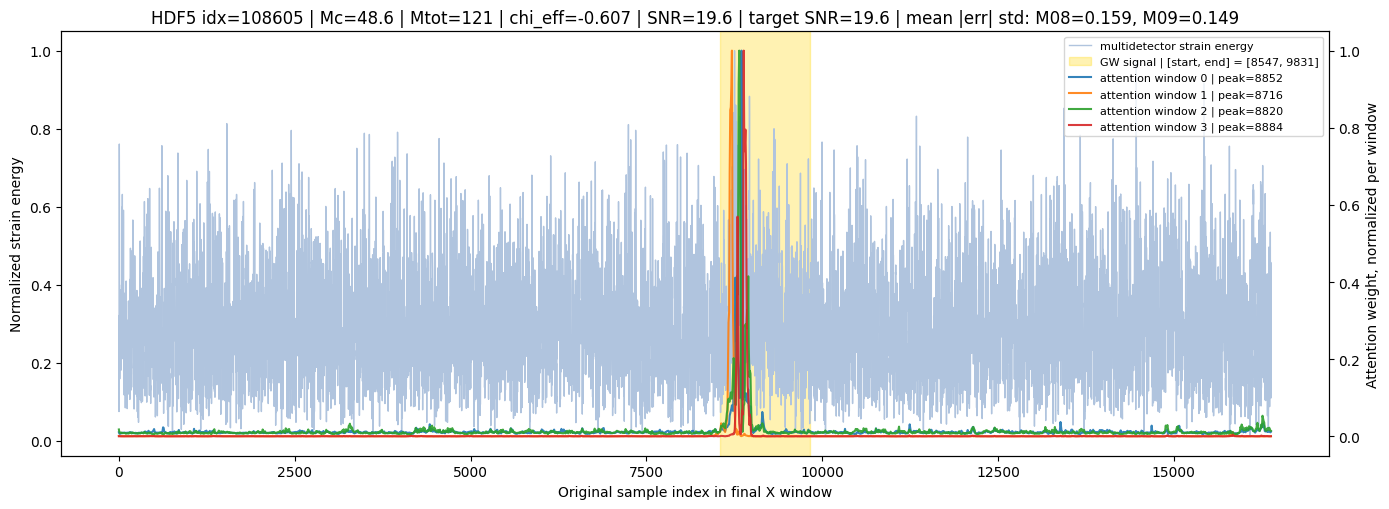

HDF5 idx=7528 | attention peak samples=[14996.5, 14828.5, 14940.5, 15044.5]
  GW region final_X_from_context_overlap: 14612–16026 width=1414
    detector spans: [('H1', 14663, 16022), ('L1', 14666, 16026), ('V1', 14612, 15972)]
  GW region final_X_from_absolute_times: 14612–16026 width=1414


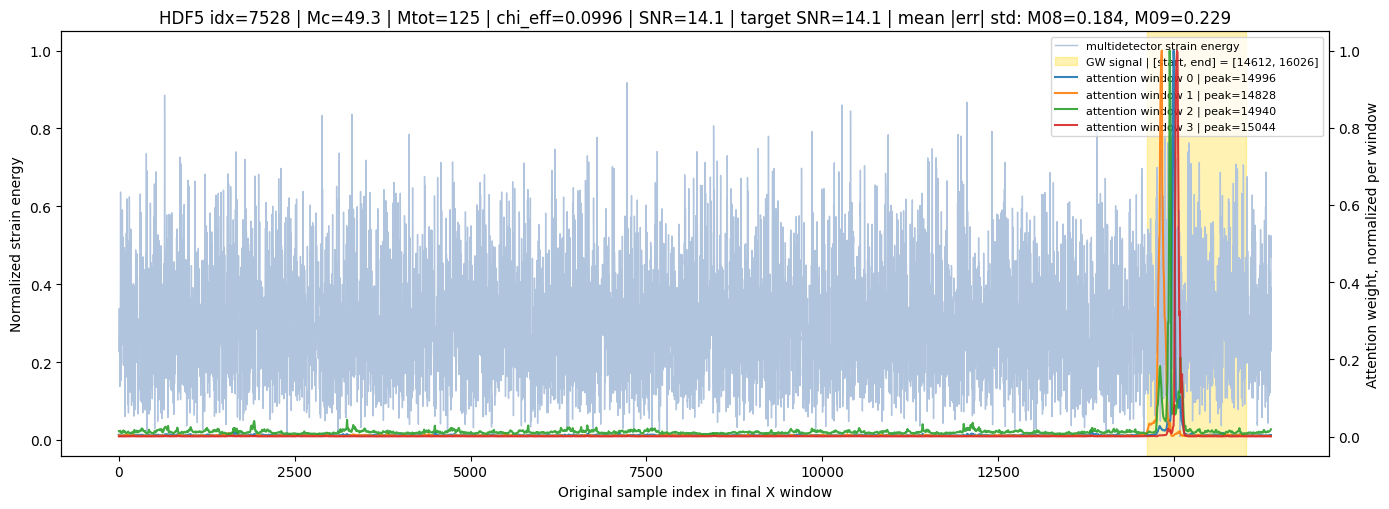

HDF5 idx=339568 | attention peak samples=[1092.5, 892.5, 1044.5, 1124.5]
  GW region final_X_from_context_overlap: 785–2004 width=1219
    detector spans: [('H1', 785, 1972), ('L1', 817, 2004), ('V1', 793, 1981)]
  GW region final_X_from_absolute_times: 785–2004 width=1219


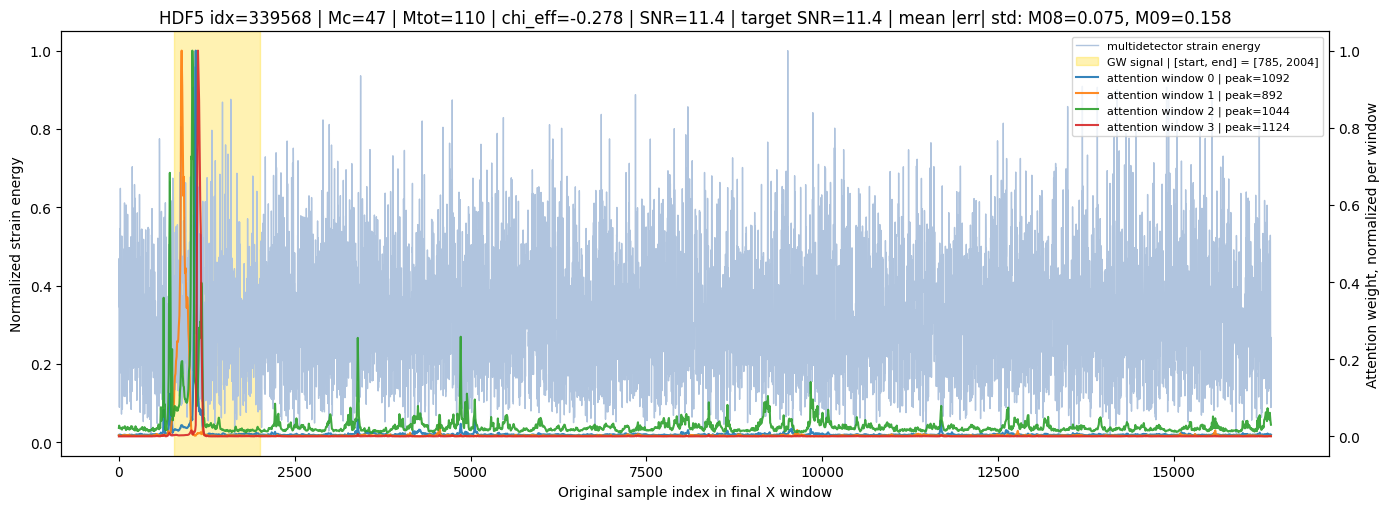

In [23]:
# ============================================================
# Attention windows + corrected final-X GW-region overlays
# ============================================================

import torch
from src.models.network import SimpleCNN_ResidualDilatedMultiAttention


def load_m09_model_from_checkpoint():
    checkpoint = torch.load(
        RUNS["M09"]["checkpoint_path"],
        map_location="cpu",
    )

    model_config = checkpoint.get("model_config", {})
    model_kwargs = model_config.get("model_kwargs", {})

    model_kwargs.setdefault("n_detectors", 3)
    model_kwargs.setdefault("n_outputs", 3)
    model_kwargs.setdefault("embedding_dim", 64)
    model_kwargs.setdefault("residual_channels", 64)
    model_kwargs.setdefault("dilations", [1, 2, 4])
    model_kwargs.setdefault("residual_kernel_size", 7)
    model_kwargs.setdefault("dropout_conv", 0.05)
    model_kwargs.setdefault("dropout_dense", 0.1)
    model_kwargs.setdefault("num_groups", 8)
    model_kwargs.setdefault("attention_slots", 4)
    model_kwargs.setdefault("attention_hidden", 64)
    model_kwargs.setdefault("attention_dropout", 0.0)
    model_kwargs.setdefault("slot_dim", 32)

    model = SimpleCNN_ResidualDilatedMultiAttention(**model_kwargs)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model


def event_title_from_metadata(row, y_true_phys=None, err_info=None):
    fields = []

    for key, label in [
        ("parameters/chirp_mass", "Mc"),
        ("parameters/total_mass", "Mtot"),
        ("parameters/chi_eff", "chi_eff"),
        ("snr/network", "SNR"),
        ("snr/target_network", "target SNR"),
    ]:
        if key in row.index and pd.notna(row[key]):
            fields.append(f"{label}={float(row[key]):.3g}")

    if y_true_phys is not None and not fields:
        fields.extend([
            f"Mc={y_true_phys[0]:.3g}",
            f"Mtot={y_true_phys[1]:.3g}",
            f"chi_eff={y_true_phys[2]:.3g}",
        ])

    if err_info is not None:
        fields.append(
            f"mean |err| std: M08={err_info['m08']:.3f}, M09={err_info['m09']:.3f}"
        )

    return " | ".join(fields)


def plot_attention_windows_with_final_x_gw_region(
    sample_positions,
    split="test",
    run_id="M09",
    max_samples=8,
    normalize_signal=True,
    show_time_crosscheck=True,
):
    dataset_path = PROCESSED_ROOT / f"{DATASET_ID}.h5"
    if not dataset_path.exists():
        dataset_path = PROCESSED_ROOT / DATASET_ID / f"{DATASET_ID}.h5"

    assert dataset_path.exists(), dataset_path

    model = load_m09_model_from_checkpoint()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    idx_split = ALIGNED[split][run_id]["idx"]

    sample_positions = np.asarray(list(sample_positions)[:max_samples], dtype=int)
    hdf5_indices = idx_split[sample_positions]

    with h5py.File(dataset_path, "r") as f:
        X = read_hdf5_dataset_preserve_order(
            h5_file=f,
            dataset_key="X",
            indices=hdf5_indices,
            dtype=np.float32,
        )

    event_metadata_table = read_event_metadata(
        dataset_path,
        hdf5_indices=hdf5_indices,
    )

    metadata_by_hdf5 = {
        int(row["hdf5_index"]): row
        for _, row in event_metadata_table.iterrows()
    }

    x_tensor = torch.from_numpy(X).to(device)

    with torch.no_grad():
        features, attention = model.get_attention_weights(x_tensor)

    attention = attention.detach().cpu().numpy()

    y_true_phys_all = inverse_standardize(ALIGNED[split][run_id]["y"])
    ae_m08_std = np.abs(ALIGNED[split]["M08"]["pred"] - ALIGNED[split][run_id]["y"])
    ae_m09_std = np.abs(ALIGNED[split]["M09"]["pred"] - ALIGNED[split][run_id]["y"])

    for local_i, hdf5_idx in enumerate(hdf5_indices):
        strain = X[local_i]
        n_detectors, signal_length = strain.shape

        energy = np.sqrt(np.mean(strain**2, axis=0))
        if normalize_signal:
            max_energy = np.max(np.abs(energy))
            energy_plot = energy / max_energy if max_energy > 0 else energy
        else:
            energy_plot = energy

        row = metadata_by_hdf5[int(hdf5_idx)]
        regions = infer_final_x_gw_regions(row, signal_length)

        attn = attention[local_i]
        original_grid = attention_to_signal_grid(
            attn,
            signal_length,
            mapping="conv_centers",
        )

        attention_peak_samples = [
            float(original_grid[np.argmax(attn[k])])
            for k in range(attn.shape[0])
        ]

        split_position = sample_positions[local_i]

        title = event_title_from_metadata(
            row,
            y_true_phys=y_true_phys_all[split_position],
            err_info={
                "m08": float(ae_m08_std[split_position].mean()),
                "m09": float(ae_m09_std[split_position].mean()),
            },
        )

        print(
            f"HDF5 idx={int(hdf5_idx)} | attention peak samples="
            f"{[round(v, 1) for v in attention_peak_samples]}"
        )
        for reg in regions:
            print(
                f"  GW region {reg['source']}: "
                f"{reg['start']}–{reg['end']} width={reg['width']}"
            )
            if reg["source"] == "final_X_from_context_overlap":
                print(
                    "    detector spans:",
                    [(s["detector"], s["start"], s["end"]) for s in reg["detector_spans"]],
                )

        fig, ax1 = plt.subplots(figsize=(14.0, 5.2))

        ax1.plot(
            np.arange(signal_length),
            energy_plot,
            linewidth=1.0,
            color="lightsteelblue",
            label="multidetector strain energy",
        )

        # Main corrected region: final X coordinates.
        for reg in regions:
            if reg["source"] == "final_X_from_context_overlap":
                ax1.axvspan(
                    reg["start"],
                    reg["end"],
                    alpha=0.30,
                    color="gold",
                    label=f"GW signal | [start, end] = [{reg['start']:.0f}, {reg['end']:.0f}]",
                )

                # # Detector-specific spans as thick horizontal marks.
                # y_levels = [-0.08, -0.12, -0.16]
                # for span, y_level in zip(reg["detector_spans"], y_levels):
                #     ax1.hlines(
                #         y=y_level,
                #         xmin=span["start"],
                #         xmax=span["end"],
                #         linewidth=4,
                #         label=f"{span['detector']} visible signal span",
                #     )

            # elif show_time_crosscheck and reg["source"] == "final_X_from_absolute_times":
            #     ax1.axvspan(
            #         reg["start"],
            #         reg["end"],
            #         alpha=0.1,
            #         hatch="//",
            #         label="GW region cross-check from times",
            #    )

        ax1.set_xlabel("Original sample index in final X window")
        ax1.set_ylabel("Normalized strain energy")
        ax1.set_title(f"HDF5 idx={int(hdf5_idx)} | {title}")

        ax2 = ax1.twinx()

        for k in range(attn.shape[0]):
            weights = attn[k]
            w = weights / np.max(weights) if np.max(weights) > 0 else weights

            ax2.plot(
                original_grid,
                w,
                linewidth=1.5,
                alpha=0.90,
                label=f"attention window {k} | peak={attention_peak_samples[k]:.0f}",
            )

        ax2.set_ylabel("Attention weight, normalized per window")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

        # Deduplicate labels.
        seen = set()
        lines = []
        labels = []
        for line, label in zip(lines1 + lines2, labels1 + labels2):
            if label not in seen:
                seen.add(label)
                lines.append(line)
                labels.append(label)

        ax1.legend(lines, labels, loc="upper right", fontsize=8)

        plt.tight_layout()
        plt.show()


# Default examples: random test samples.
rng = np.random.default_rng(123)
sample_positions = rng.choice(
    len(ALIGNED["test"]["M09"]["idx"]),
    size=6,
    replace=False,
)

plot_attention_windows_with_final_x_gw_region(
    sample_positions=sample_positions,
    split="test",
    run_id="M09",
    max_samples=6,
)


M09 aprende a concentrar el pooling en una o varias regiones discriminativas
del mapa de features, que suelen estar dentro de la señal y a menudo cerca
de zonas de alta energía o transición rápida.

## 22. Select interpretable events for attention-window inspection

This repeats the same plotting logic for events where M09 helps, events where M09 hurts, and the lowest/highest-mass systems. These examples are better for interpretation than random draws.


In [24]:
# ============================================================
# Select interpretable events for attention-window inspection
# ============================================================

def build_event_selection_table(split="test"):
    y_true_std = ALIGNED[split]["M09"]["y"]
    pred_m08_std = ALIGNED[split]["M08"]["pred"]
    pred_m09_std = ALIGNED[split]["M09"]["pred"]

    y_true_phys = inverse_standardize(y_true_std)

    ae_m08_std = np.abs(pred_m08_std - y_true_std)
    ae_m09_std = np.abs(pred_m09_std - y_true_std)

    rows = []

    for i, hdf5_idx in enumerate(ALIGNED[split]["M09"]["idx"]):
        rows.append({
            "position": i,
            "hdf5_index": int(hdf5_idx),
            "chirp_mass": y_true_phys[i, 0],
            "total_mass": y_true_phys[i, 1],
            "chi_eff": y_true_phys[i, 2],
            "ae_m08_mean_std": ae_m08_std[i].mean(),
            "ae_m09_mean_std": ae_m09_std[i].mean(),
            "m09_minus_m08_ae_mean_std": ae_m09_std[i].mean() - ae_m08_std[i].mean(),
            "ae_m08_chirp_std": ae_m08_std[i, 0],
            "ae_m09_chirp_std": ae_m09_std[i, 0],
            "ae_m08_total_std": ae_m08_std[i, 1],
            "ae_m09_total_std": ae_m09_std[i, 1],
            "ae_m08_chi_std": ae_m08_std[i, 2],
            "ae_m09_chi_std": ae_m09_std[i, 2],
        })

    df = pd.DataFrame(rows)

    selected = []

    selected.append(
        df.nsmallest(3, "m09_minus_m08_ae_mean_std")
        .assign(selection_reason="M09 helps most")
    )

    selected.append(
        df.nlargest(3, "m09_minus_m08_ae_mean_std")
        .assign(selection_reason="M09 hurts most")
    )

    selected.append(
        df.nsmallest(3, "total_mass")
        .assign(selection_reason="lowest total mass / longest signals")
    )

    selected.append(
        df.nlargest(3, "total_mass")
        .assign(selection_reason="highest total mass / shortest signals")
    )

    selected.append(
        df.nlargest(3, "ae_m09_chi_std")
        .assign(selection_reason="largest chi_eff error in M09")
    )

    out = pd.concat(selected, ignore_index=True)
    out = out.drop_duplicates(subset=["position"]).reset_index(drop=True)

    return out


event_selection_df = build_event_selection_table(split="test")
display(event_selection_df)




,position,hdf5_index,chirp_mass,total_mass,chi_eff,ae_m08_mean_std,ae_m09_mean_std,m09_minus_m08_ae_mean_std,ae_m08_chirp_std,ae_m09_chirp_std,ae_m08_total_std,ae_m09_total_std,ae_m08_chi_std,ae_m09_chi_std,selection_reason
0,21059,349777,16.050084,50.952674,-0.492307,1.090499,0.155214,-0.935285,0.394526,0.002541,0.851336,0.181226,2.025636,0.281877,M09 helps most
1,28643,477478,40.110832,108.108612,-0.741669,1.635540,0.729501,-0.906039,1.291864,0.542590,1.721307,0.274214,1.893448,1.371699,M09 helps most
2,22062,366905,27.721666,101.242844,-0.692642,1.382940,0.556236,-0.826704,0.631896,0.134401,1.592790,0.468058,1.924133,1.066248,M09 helps most
3,21930,364523,8.590120,20.903596,0.658130,0.329306,1.994707,1.665401,0.100771,1.396155,0.160420,1.876821,0.726727,2.711145,M09 hurts most
4,22814,379530,43.963173,103.048157,-0.530202,0.345955,1.251309,0.905353,0.490191,1.241858,0.313059,1.171544,0.234617,1.340523,M09 hurts most
5,10722,177331,49.424542,113.586357,0.300494,0.220815,0.953750,0.732935,0.389375,1.088095,0.127536,0.638551,0.145534,1.134605,M09 hurts most
6,886,14990,4.573941,10.519634,-0.198529,0.396532,0.397404,0.000872,0.165087,0.187507,0.169741,0.210948,0.854768,0.793756,lowest total mass / longest signals
7,16304,270942,4.641007,10.666585,0.023026,0.397434,0.347317,-0.050117,0.300958,0.251119,0.379424,0.290863,0.511921,0.499969,lowest total mass / longest signals
8,9547,157776,4.665881,10.744224,0.116639,0.292247,0.302209,0.009962,0.371639,0.377745,0.477445,0.458097,0.027656,0.070786,lowest total mass / longest signals
9,18771,310990,77.771958,178.673126,-0.249747,0.627549,0.643163,0.015615,0.413067,0.462342,0.460677,0.503812,1.008902,0.963335,highest total mass / shortest signals


## 23. Interpretation of attention-window overlays

The corrected coordinate mapping shows that the injected GW span in the final model input is obtained by subtracting the processing-context offset from the injection overlap indices.

This fixes the earlier apparent mismatch where the shaded GW region was systematically shifted to the right by approximately `processing_context_start_samples` samples.

The relevant mapping is:

```text
final_X_index = injection_context_index - processing_context_start_samples
```

The attention windows themselves are mapped from encoder index to final-X sample index using the centers of the three stride-2 convolutional blocks. This is an approximate center mapping, not a full receptive-field display. The real receptive fields are wider because the residual dilated blocks enlarge temporal context, but their centers remain aligned with the encoder positions.

Practical conclusion:

```text
M08 remains the operational baseline.
M09 is a positive but marginal pooling ablation.
The M09 attention windows are non-uniform and can be inspected against the corrected final-X GW span, but the predictive improvement remains too small to justify replacing M08.
```

For a report, do not overclaim that the windows identify merger/inspiral/ringdown unless you add a dedicated analysis of window centers versus physical event duration, mass, SNR, and error improvement.


## 24. Receptive-field-aware interpretation

The corrected GW-span overlay now uses the final model-input coordinate system. The injected signal span is obtained from the injection indices in the longer processing-context segment after subtracting the left processing context:

```text
final_X_index = injection_context_index - processing_context_start_samples
```

Therefore, the previous systematic offset has been removed.

The attention-window peaks should still not be interpreted as infinitesimally localized samples. M09 has three stride-2 convolutional blocks before the residual-dilated encoder. A rough receptive-field estimate for the temporal feature map is:

```text
initial receptive field after three stride-2 ConvBlocks: ~106 input samples
residual block d=1: +96 samples
residual block d=2: +192 samples
residual block d=4: +384 samples
total approximate receptive field: ~778 input samples
effective stride: 8 input samples per encoder index
```

So an attention peak at final-X sample index `p` should be read as attending to a region of order

```text
p ± 390 samples
```

not exactly to one original sample.

This matters for short high-mass signals. In those cases the injected GW span may be only around 1000–1500 samples long, and an attention peak near the early/high-amplitude part of the span can still cover a substantial part of the merger/ringdown region through its receptive field.

The plots therefore support this conservative interpretation:

- The M09 attention windows are now reasonably aligned with the corrected GW span.
- For short/high-mass events, several windows collapse near a compact high-information region.
- For longer/lower-mass events, some windows spread more broadly across the injected span.
- This behavior is plausible and not obviously a plotting artifact.
- However, it is not enough to claim that the model explicitly separates inspiral, merger, and ringdown.

The correct wording is:

```text
The attention windows provide a qualitative diagnostic of where the M09 encoder concentrates information. They often lie inside the corrected injected-signal span and sometimes respond to compact high-amplitude regions, but the quantitative performance gain over M08 remains marginal.
```


In [25]:
# ============================================================
# Receptive-field estimate for M08/M09 temporal feature map
# ============================================================

def estimate_m08_m09_receptive_field():
    """
    Approximate receptive field in original input samples.

    Architecture assumptions:
    - Three ConvBlocks before the residual blocks.
    - Each ConvBlock: kernel_size=16, stride=2.
    - Residual dilated blocks: two Conv1d layers per block.
    - residual_kernel_size=7.
    - dilations=[1, 2, 4].
    - Projection and pooling do not change receptive-field size.
    """
    receptive_field = 1
    jump = 1

    # Three initial stride-2 ConvBlocks.
    for _ in range(3):
        kernel = 16
        stride = 2
        dilation = 1
        receptive_field += (kernel - 1) * dilation * jump
        jump *= stride

    # Residual dilated blocks.
    # Each block has two convolutions.
    residual_kernel = 7
    for dilation in [1, 2, 4]:
        for _ in range(2):
            receptive_field += (residual_kernel - 1) * dilation * jump

    return {
        "approx_receptive_field_samples": receptive_field,
        "effective_stride_samples": jump,
        "half_receptive_field_samples": receptive_field / 2,
    }


rf_info = estimate_m08_m09_receptive_field()
rf_info


{'approx_receptive_field_samples': 778,
 'effective_stride_samples': 8,
 'half_receptive_field_samples': 389.0}

The corrected attention-window overlay shows that M09 generally places its
learned pooling weights inside the injected-signal region. However, the windows
should not be interpreted as direct physical labels for inspiral, merger, or
ringdown. They act on encoder features, whose temporal positions already
aggregate several hundred input samples through the convolutional receptive
field.

For short, high-mass systems, the informative part of the waveform is highly
compressed in time. The attention windows often collapse onto a compact region
near the strongest encoder response, rather than spreading over the full
injected span. For longer, lower-mass systems, the signal occupies a broader
time interval and the windows can distribute more broadly across the late
inspiral/merger region.

Thus, M09 provides qualitatively meaningful attention diagnostics, but its
small improvement over M08 indicates that temporal pooling was not the dominant
performance bottleneck.

## 25. Final closure

### Decision

M08 remains the operational baseline.

M09 is retained as a positive but marginal pooling ablation. It improves the fixed-seed test metrics slightly, especially for total mass, but the gain is small, weaker than the observed M08 seed-to-seed variability, and accompanied by stronger contraction for `chi_eff`.

### What the attention-window plots show

After correcting the coordinate convention, the yellow GW span and the attention windows are no longer systematically mismatched. The previous mismatch was caused by plotting injection-context indices directly on the final 4 s model input. The corrected mapping subtracts the processing-context offset.

The current plots suggest that M09 attention windows often fall inside the injected GW region. For short high-mass events, the windows frequently concentrate near a compact high-amplitude part of the signal. This is plausible because the useful information is temporally compressed and each encoder index has a broad receptive field of roughly several hundred input samples.

For longer signals, the windows can be more spread across the injected span, which is qualitatively consistent with the idea that longer inspiral-dominated signals distribute information over a larger time interval.

### What should not be overclaimed

The attention windows should not be described as direct physical segment labels. They are learned pooling weights over encoder features, not explicit inspiral/merger/ringdown annotations. Because the encoder feature at one time index already summarizes a broad receptive field, a narrow attention peak can still integrate nearby signal context.

Therefore, the final scientific conclusion is:

```text
M09 learns non-uniform temporal pooling windows that are qualitatively aligned with the corrected injected-signal region, but this interpretability does not translate into a large predictive gain. M08 remains the baseline for the main conformal/Mondrian analysis.
```

### Next-step policy

Do not spend more time on pooling-only variants now. The next useful step is to finish the M00 vs M08 conformal/Mondrian story, then decide whether to explore either a deeper residual-dilated/TCN encoder or a more physically targeted diagnostic of failure modes by mass, duration, SNR, and `chi_eff`.


_______________________________________

## Plot generation

In [28]:
# ============================================================
# Predicted vs true density with clean marginal line histograms
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def _hist_line(values, bins=70, range_=None, density=True):
    counts, edges = np.histogram(
        values,
        bins=bins,
        range=range_,
        density=density,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts


def plot_pred_true_with_marginal_lines(
    y_true,
    y_pred,
    label,
    bins=80,
    gridsize=75,
    cmap="viridis",
    save=True,
    model_name="M08",
):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite]
    y_pred = y_pred[finite]

    vmin = min(np.min(y_true), np.min(y_pred))
    vmax = max(np.max(y_true), np.max(y_pred))
    pad = 0.04 * (vmax - vmin if vmax > vmin else 1.0)
    lims = (vmin - pad, vmax + pad)

    # Wider figure and explicit colorbar column.
    fig = plt.figure(figsize=(8.2, 7.4))

    gs = GridSpec(
        2,
        3,
        figure=fig,
        width_ratios=[5.2, 1.05, 0.22],
        height_ratios=[1.05, 5.2],
        hspace=0.06,
        wspace=0.12,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_main = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
    cax = fig.add_subplot(gs[1, 2])

    # --------------------------------------------------------
    # Main density
    # --------------------------------------------------------
    hb = ax_main.hexbin(
        y_true,
        y_pred,
        gridsize=gridsize,
        bins="log",
        mincnt=1,
        cmap=cmap,
        linewidths=0.0,
    )

    ax_main.plot(
        lims,
        lims,
        linestyle="--",
        linewidth=1.5,
        color=PRED_COLORS["diag"],
        alpha=0.95,
        label="ideal prediction",
    )

    ax_main.set_xlim(lims)
    ax_main.set_ylim(lims)

    unit = _get_label_unit(label)
    tex = _get_label_tex(label)

    if unit:
        ax_main.set_xlabel(f"True {tex} [{unit}]")
        ax_main.set_ylabel(f"Predicted {tex} [{unit}]")
    else:
        ax_main.set_xlabel(f"True {tex}")
        ax_main.set_ylabel(f"Predicted {tex}")

    style_axis_clean(ax_main)

    # Colorbar in its own axis, so it cannot overlap.
    cbar = fig.colorbar(hb, cax=cax)
    cbar.set_label(r"$\log_{10}(\mathrm{count})$", rotation=90)

    # --------------------------------------------------------
    # Top marginal: line histograms
    # --------------------------------------------------------
    x_true, d_true = _hist_line(
        y_true,
        bins=bins,
        range_=lims,
        density=True,
    )
    x_pred_top, d_pred_top = _hist_line(
        y_pred,
        bins=bins,
        range_=lims,
        density=True,
    )

    ax_top.plot(
        x_true,
        d_true,
        color=PRED_COLORS["true_hist"],
        linewidth=2.0,
        label="True",
    )
    ax_top.plot(
        x_pred_top,
        d_pred_top,
        color=PRED_COLORS["pred_hist"],
        linewidth=2.0,
        linestyle="--",
        label="Predicted",
    )

    ax_top.set_xlim(lims)
    ax_top.set_ylabel("Density", fontsize=10)
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_top.legend(
        frameon=False,
        loc="upper right",
        ncol=2,
        fontsize=9,
        handlelength=2.2,
    )
    style_axis_clean(ax_top)

    # --------------------------------------------------------
    # Right marginal: horizontal line histograms
    # --------------------------------------------------------
    y_true_centers, d_true_y = _hist_line(
        y_true,
        bins=bins,
        range_=lims,
        density=True,
    )
    y_pred_centers, d_pred_y = _hist_line(
        y_pred,
        bins=bins,
        range_=lims,
        density=True,
    )

    ax_right.plot(
        d_true_y,
        y_true_centers,
        color=PRED_COLORS["true_hist"],
        linewidth=2.0,
    )
    ax_right.plot(
        d_pred_y,
        y_pred_centers,
        color=PRED_COLORS["pred_hist"],
        linewidth=2.0,
        linestyle="--",
    )

    ax_right.set_ylim(lims)
    ax_right.set_xlabel("Density", fontsize=10)
    ax_right.tick_params(axis="y", labelleft=False)
    style_axis_clean(ax_right)

    # Keep marginal density axes compact and clean.
    ax_top.set_ylim(bottom=0.0)
    ax_right.set_xlim(left=0.0)

    # Remove duplicated clutter.
    ax_top.spines["right"].set_visible(False)
    ax_right.spines["top"].set_visible(False)

    fig.suptitle(
        f"{model_name}: true vs predicted density with marginal distributions — {tex}",
        fontsize=15.5,
        color=PRED_COLORS["title"],
        y=0.985,
    )

    if save:
        savefig_clean(fig, f"{model_name.lower()}_pred_true_marginal_lines_{label}")

    plt.show()

Saved: m08_pred_true_marginal_lines_chirp_mass.png m08_pred_true_marginal_lines_chirp_mass.pdf


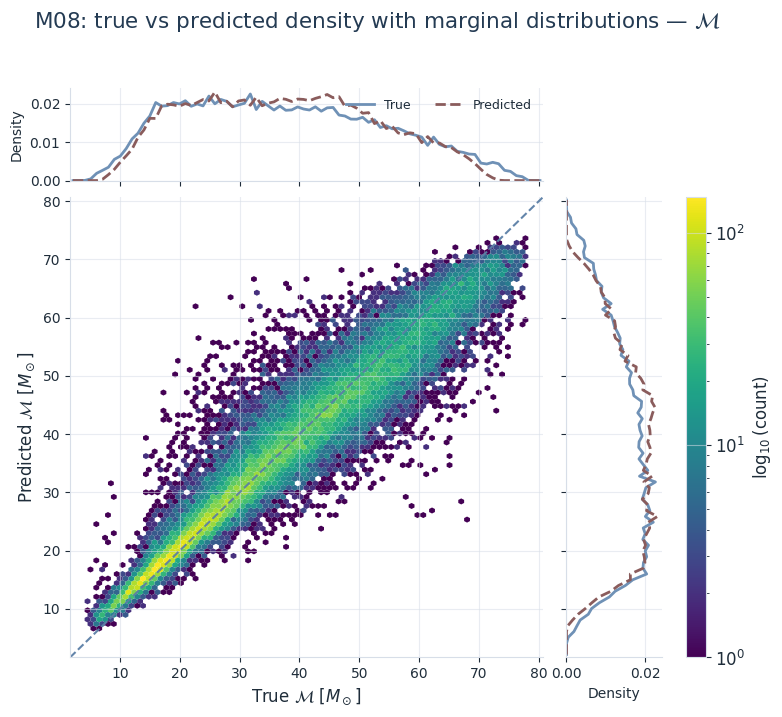

Saved: m08_pred_true_marginal_lines_total_mass.png m08_pred_true_marginal_lines_total_mass.pdf


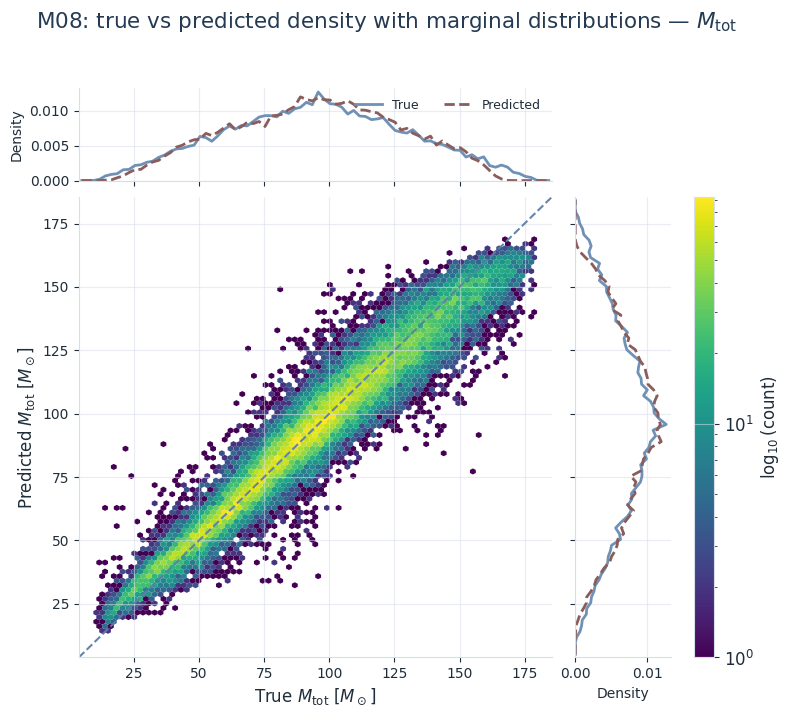

Saved: m08_pred_true_marginal_lines_chi_eff.png m08_pred_true_marginal_lines_chi_eff.pdf


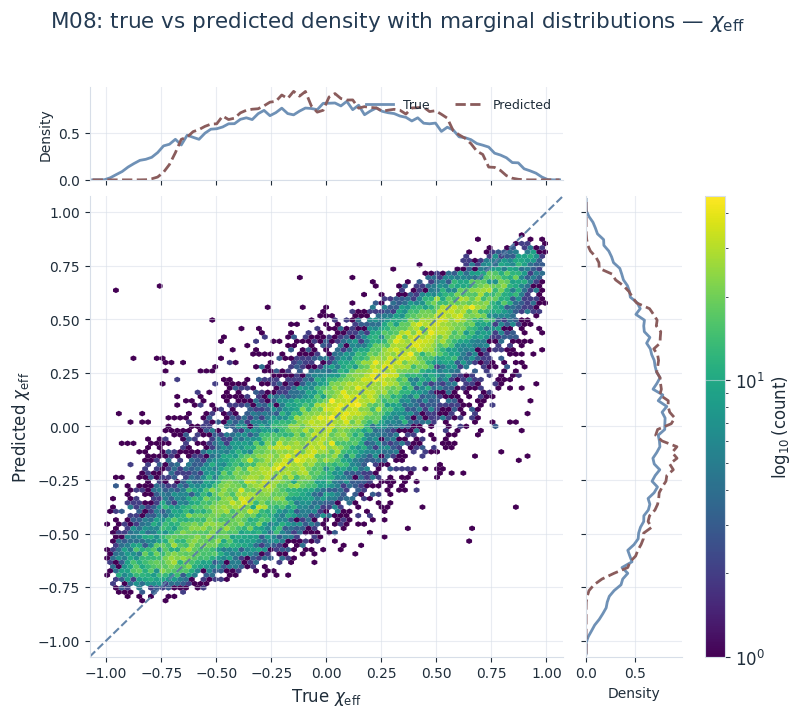

In [29]:
for i, label in enumerate(_label_names):
    plot_pred_true_with_marginal_lines(
        TRUE_PHYS[:, i],
        PRED_PHYS[:, i],
        label=label,
        bins=80,
        gridsize=75,
        cmap="viridis",
        save=True,
        model_name="M08",
    )